In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

TITLE_FSIZE = 14
LABEL_FSIZE = 12
TICK_FSIZE = 10
REF_LINE_COLOR = 'gray'

plt.rc('text', usetex=True)
plt.rc('font', family='serif') # no global size here
plt.rc('grid', linestyle='--', alpha=0.3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.1

# Data

In [2]:
csv_file = "heis_sdrg.csv" 

# Fig.1 - Supplemental Material

Selected EA L: [ 12.  16.  20.  24.  28.  32.  36.  40.  44.  48.  52.  56.  60.  64.
  68.  72.  76.  80.  84.  88.  92.  96. 100.]
Selected FM L: [12. 16. 20. 24. 28.]
Saved high-quality PDF as: Figs/AFM-Heisenberg-SDRG.pdf


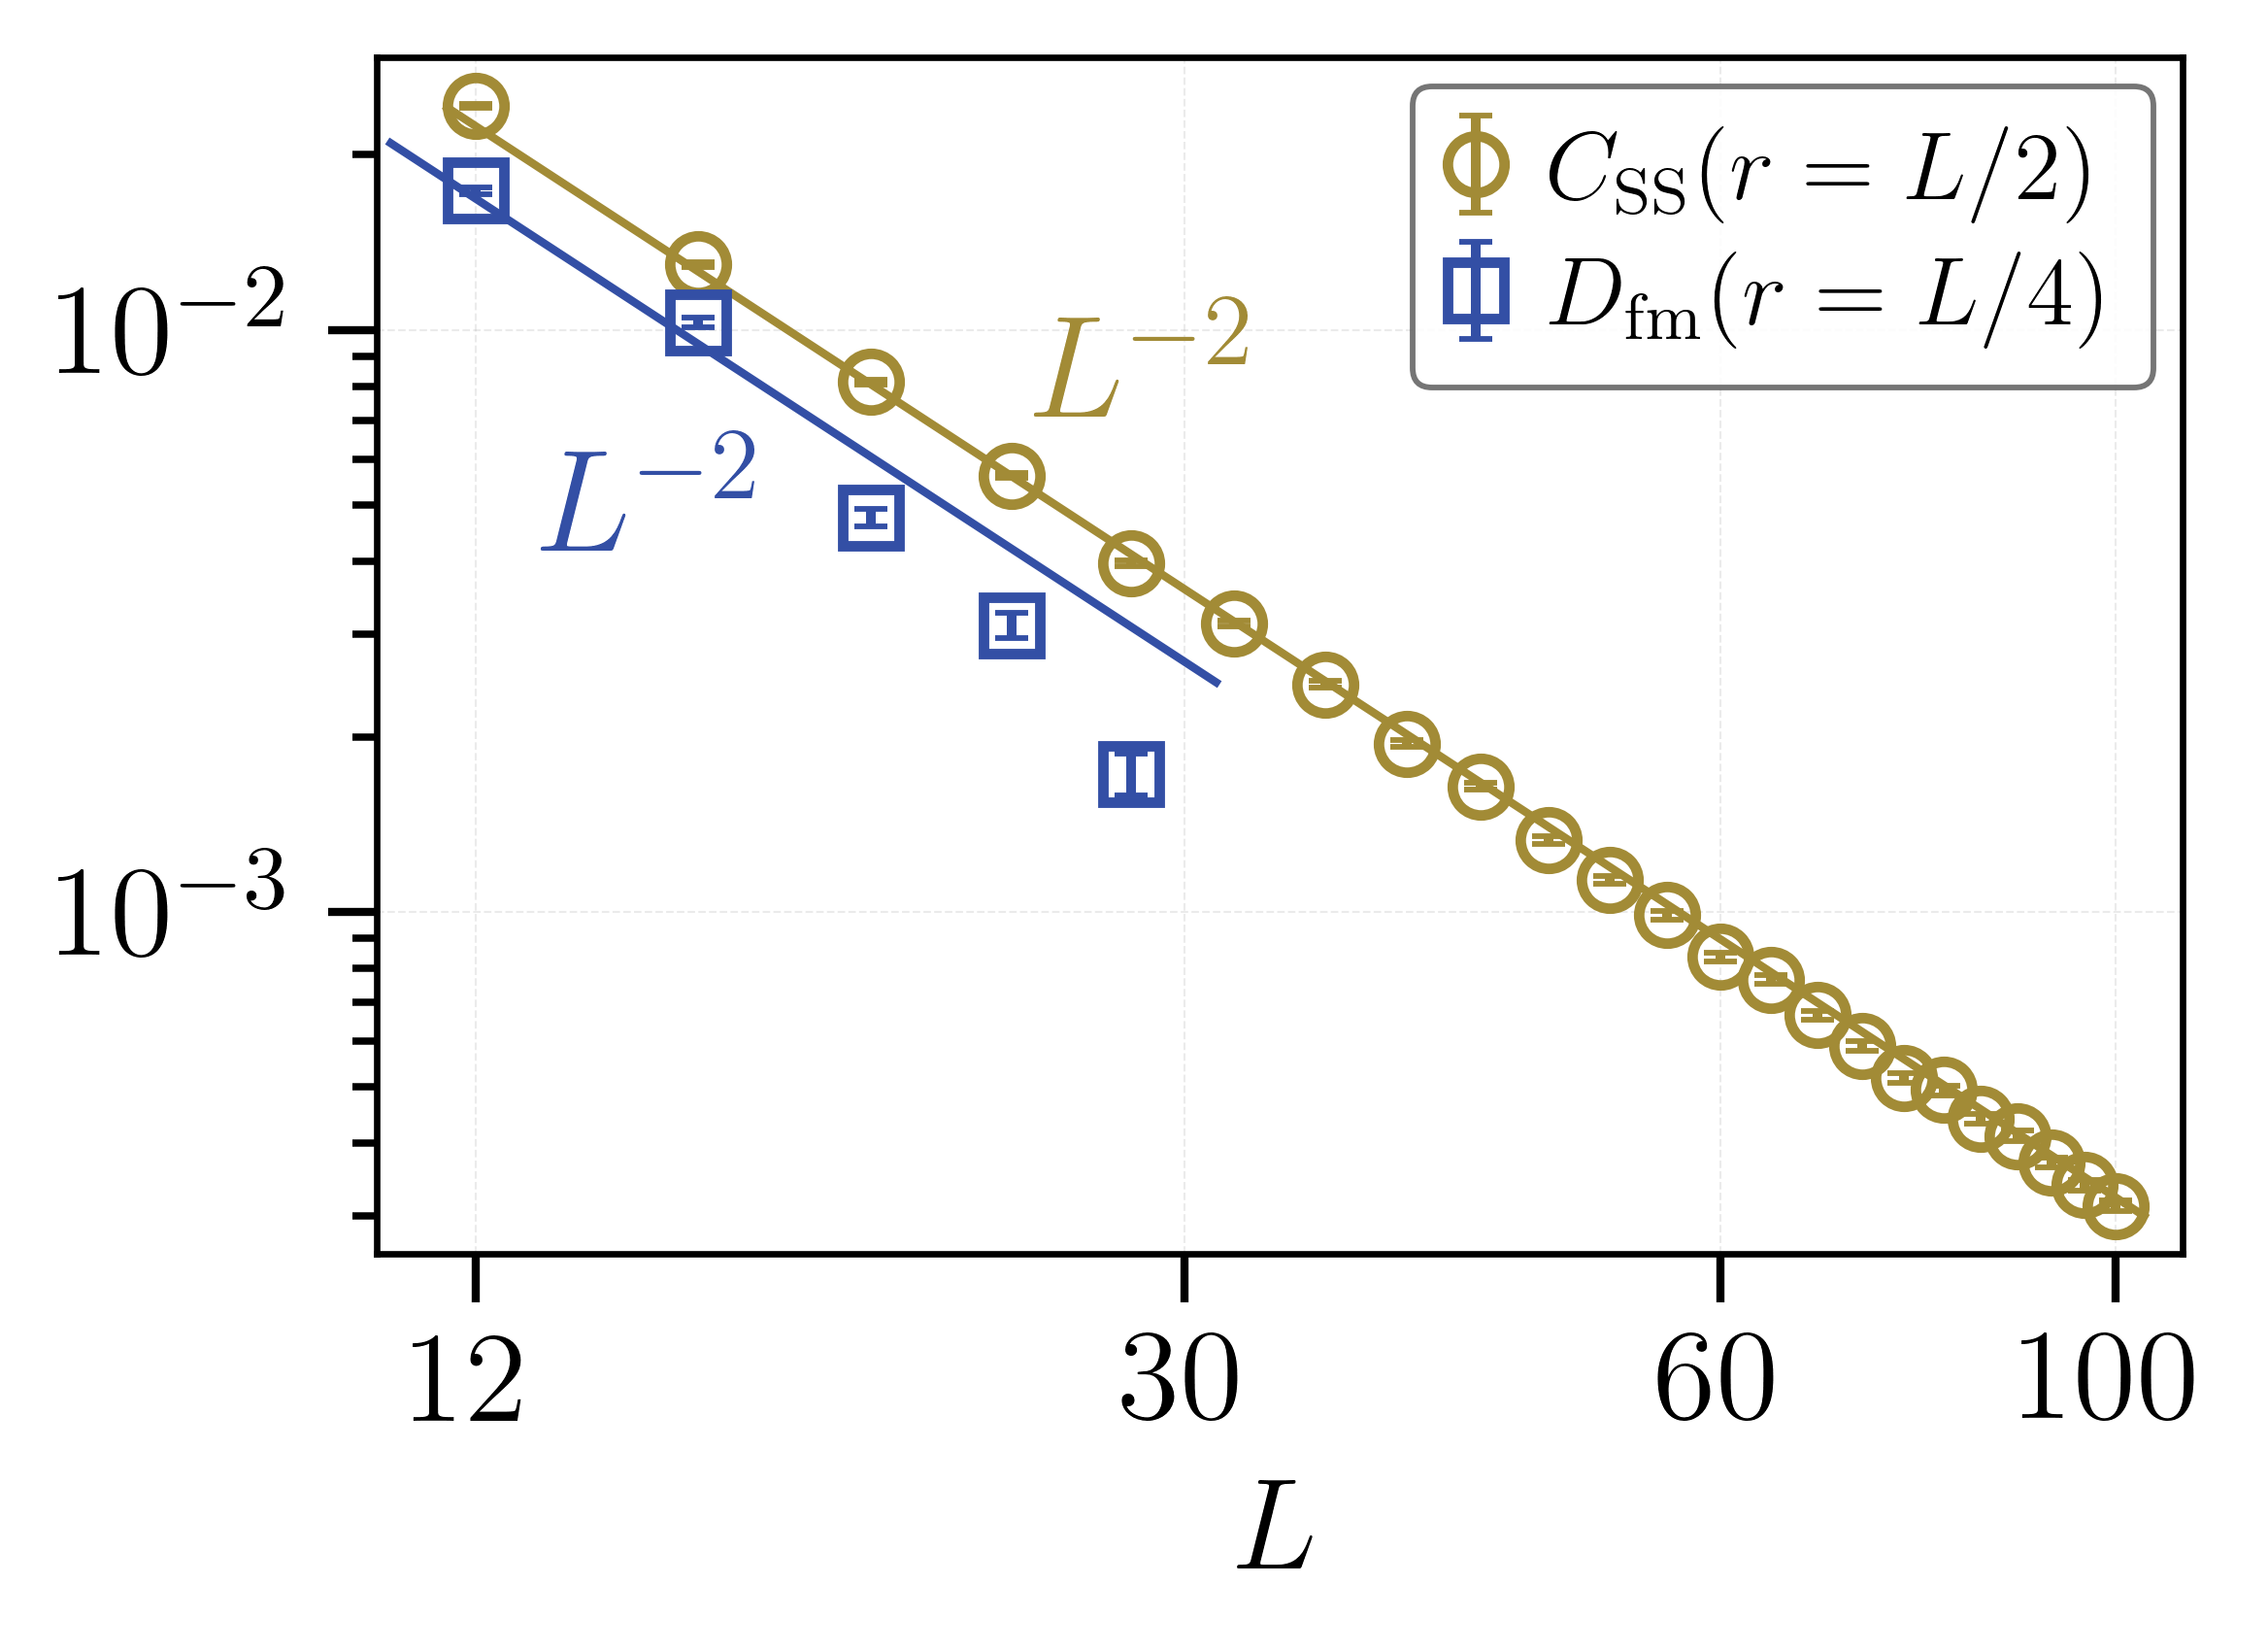

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings 
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

snr_cut = 10

# ---------------------------------------------------------
# Colors 
# ---------------------------------------------------------
ce_color  = '#a28b36ff'   # C_EA
dfm_color = '#334fa5ff'   # D_fm

# ---------------------------------------------------------
# ---------------------------------------------------------
def fit_A_fixed_m_minus2(L, y, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")

    logA_samples = np.log(y) + 2.0 * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, Lmin, Lmax, frac, y_mult, color,
                                 text=r'$L^{-2}$', fontsize=ANNOT_FSIZE,
                                 ha='left', va='center'):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-2))
    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha=ha, va=va,
        zorder=6
    )

def extend_logL_span_for_marker(ax, Lmin, Lmax, markersize_pts, where="both"):

    fig = ax.figure
    fig.canvas.draw()  

    r_pix = 0.5 * markersize_pts * fig.dpi / 72.0

    def delta_log10L_at(L0):
        eps = 0.01
        L1 = L0 * (1.0 + eps)
        x0 = ax.transData.transform((L0, 1.0))[0]
        x1 = ax.transData.transform((L1, 1.0))[0]
        dx = abs(x1 - x0)
        if dx <= 1e-9:
            return 0.01
        dlog10 = abs(np.log10(L1) - np.log10(L0))
        pix_per_log10 = dx / dlog10
        return r_pix / pix_per_log10

    logLmin, logLmax = np.log10(Lmin), np.log10(Lmax)

    if where in ("both", "left"):
        logLmin -= delta_log10L_at(Lmin)
    if where in ("both", "right"):
        logLmax += delta_log10L_at(Lmax)

    return 10**logLmin, 10**logLmax

# ============================================================
# ============================================================
def _collect_fixed_fraction_vs_L_single_obs(
    df,
    frac,                
    mean_col,
    se_col,
    snr_cut=10.0,
    r_min=3,
    parity=None           
):
    num, den = frac
    L_vals = np.sort(df["L"].unique())

    L_sel_list, y_list, se_list = [], [], []

    for L in L_vals:
        if L % den != 0:
            continue

        r = (num * L) // den
        if r * den != num * L:
            continue

        if parity == "odd" and (r % 2 == 0):
            r -= 1
        if parity == "even" and (r % 2 == 1):
            r -= 1

        if r < r_min:
            continue

        row = df[(df["L"] == L) & (df["r"] == r)]
        if row.empty:
            continue

        mean_val = row[mean_col].values[0]
        se_val   = row[se_col].values[0]

        y_val = ((-1)**r) * mean_val

        if not (np.isfinite(y_val) and np.isfinite(se_val) and y_val > 0 and se_val > 0):
            continue

        snr_val = float(y_val / se_val)
        if not (np.isfinite(snr_val) and snr_val >= snr_cut):
            continue

        L_sel_list.append(L)
        y_list.append(y_val)
        se_list.append(se_val)

    L_arr = np.array(L_sel_list, dtype=float)
    y_arr = np.array(y_list, dtype=float)
    e_arr = np.array(se_list, dtype=float)

    if len(L_arr) > 0:
        order = np.argsort(L_arr)
        L_arr, y_arr, e_arr = L_arr[order], y_arr[order], e_arr[order]

    return L_arr, y_arr, e_arr

def _pick_label_from_frac(frac):
    num, den = frac
    if num == 1:
        return rf"r=L/{den}"
    return rf"r=\frac{{{num}}}{{{den}}}L"
def extend_logL_span_for_marker(ax, Lmin, Lmax, markersize_pts, where="both", extra=1.0):
    fig = ax.figure
    fig.canvas.draw()
    r_pix = 0.5 * markersize_pts * fig.dpi / 72.0

    def delta_log10L_at(L0):
        eps = 0.01
        L1 = L0 * (1.0 + eps)
        x0 = ax.transData.transform((L0, 1.0))[0]
        x1 = ax.transData.transform((L1, 1.0))[0]
        dx = abs(x1 - x0)
        if dx <= 1e-9:
            return 0.01
        dlog10 = abs(np.log10(L1) - np.log10(L0))
        pix_per_log10 = dx / dlog10
        return extra * (r_pix / pix_per_log10)   

    logLmin, logLmax = np.log10(Lmin), np.log10(Lmax)
    if where in ("both", "left"):
        logLmin -= delta_log10L_at(Lmin)
    if where in ("both", "right"):
        logLmax += delta_log10L_at(Lmax)
    return 10**logLmin, 10**logLmax

# ============================================================
# ============================================================
def plot_EA_FM_fixed_frac_reference_style(
    frac_EA=(1, 2),
    frac_FM=(1, 4),
    csv_file=None,
    snr_cut_EA=10.0,
    snr_cut_FM=10.0,
    r_min=3,
    title=None,
    L_ticks=(12, 30, 60, 100),
    pdf_name=None,
    debug=False,

    ann_EA=(0.30, 1.8,  r'$L^{-2}$'),
    ann_FM=(0.37, 0.34, r'$L^{-2}$'),
):
    if csv_file is None:
        raise ValueError("csv_file must be provided.")
    df = pd.read_csv(csv_file)

    L_EA, y_EA, e_EA = _collect_fixed_fraction_vs_L_single_obs(
        df, frac=frac_EA,
        mean_col="sij_mean", se_col="sij_se",
        snr_cut=snr_cut_EA, r_min=r_min,
        parity="odd",
    )
    L_FM, y_FM, e_FM = _collect_fixed_fraction_vs_L_single_obs(
        df, frac=frac_FM,
        mean_col="ddij_mean", se_col="ddij_se",
        snr_cut=snr_cut_FM, r_min=r_min,
        parity=None,
    )

    if debug:
        print("Selected EA L:", L_EA)
        print("Selected FM L:", L_FM)

    if len(L_EA) == 0 and len(L_FM) == 0:
        raise ValueError("No points available to plot after cuts.")

    fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

    # ---- plot points ----
    msize = 7  

    if len(L_EA) > 0:
        eb = ax.errorbar(
            L_EA, y_EA, yerr=e_EA,
            fmt='o', color=ce_color, ecolor=ce_color,
            markersize=msize, markerfacecolor='none',
            capsize=2, elinewidth=1.2, capthick=0.7,
            label=rf'$C_{{\mathrm{{SS}}}}({ _pick_label_from_frac(frac_EA) })$',
            zorder=3
        )
        eb[0].set_markeredgewidth(1.3)

    if len(L_FM) > 0:
        eb = ax.errorbar(
            L_FM, y_FM, yerr=e_FM,
            fmt='s', color=dfm_color, ecolor=dfm_color,
            markersize=msize, markerfacecolor='none',
            capsize=2, elinewidth=1.2, capthick=0.7,
            label=rf'$D_{{\mathrm{{fm}}}}({ _pick_label_from_frac(frac_FM) })$',
            zorder=3
        )
        eb[0].set_markeredgewidth(1.3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.88 * min(L_ticks), 1.09 * max(L_ticks))

    A_cea = None
    if len(L_EA) > 0:
        A_cea = fit_A_fixed_m_minus2(L_EA, y_EA, yerr=e_EA)
        Lmin_ext, Lmax_ext = extend_logL_span_for_marker(ax, L_EA.min(), L_EA.max(), msize, where="both")
        L_fit_EA = np.logspace(np.log10(Lmin_ext), np.log10(Lmax_ext), 500)
        ax.plot(L_fit_EA, A_cea * L_fit_EA**(-2), color=ce_color, lw=1.0, zorder=2)

    A_dfm = None
    if len(L_FM) > 0:
        A_dfm = fit_A_fixed_m_minus2(L_FM, y_FM, yerr=e_FM)
        Lmin_ext, Lmax_ext = extend_logL_span_for_marker(
            ax, L_FM.min(), L_FM.max(), msize, where="both", extra=3
        )
        L_fit_FM = np.logspace(np.log10(Lmin_ext), np.log10(Lmax_ext), 500)
        ax.plot(L_fit_FM, A_dfm * L_fit_FM**(-2), color=dfm_color, lw=1.0, zorder=2)


    # ---- annotations ----
    if A_cea is not None:
        f, ym, txt = ann_EA
        place_scaling_label_near_line(ax, A_cea, L_EA.min(), L_EA.max(),
                                      frac=f, y_mult=ym, color=ce_color, text=txt)
    if A_dfm is not None:
        f, ym, txt = ann_FM
        place_scaling_label_near_line(ax, A_dfm, L_FM.min(), L_FM.max()+6,
                                      frac=f, y_mult=ym, color=dfm_color, text=txt)

    # ---- axes formatting ----
    ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
    ax.set_title(title, fontsize=LABEL_FSIZE + 1)

    ax.set_xticks(list(L_ticks))
    ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

    y_pool = []
    if len(y_EA) > 0: y_pool.append(y_EA)
    if len(y_FM) > 0: y_pool.append(y_FM)
    if A_cea is not None:
        y_pool.append(np.array([A_cea * (L_EA.min()**(-2)), A_cea * (L_EA.max()**(-2))]))
    if A_dfm is not None:
        y_pool.append(np.array([A_dfm * (L_FM.min()**(-2)), A_dfm * (L_FM.max()**(-2))]))

    all_y = np.concatenate(y_pool)
    y_min, y_max = float(np.min(all_y)), float(np.max(all_y))
    ax.set_ylim(y_min / 1.21, y_max * 1.21)


    leg = ax.legend(
        fontsize=LEGEND_FONTSIZE,
        loc='upper right',
        handlelength=0.5,
        handletextpad=0.5,
        borderpad=0.4,
        labelspacing=0.3,
        borderaxespad=0.3,
        frameon=True,
    )
    frame = leg.get_frame()
    frame.set_edgecolor('0.4')   # medium gray
    frame.set_linewidth(0.7)
    frame.set_facecolor('white')
    frame.set_alpha(0.9)
    if pdf_name is not None:
        plt.savefig(
            pdf_name,
            format="pdf",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.08,
            transparent=False
        )
    print(f"Saved high-quality PDF as: {pdf_name}")

    plt.show()
    return fig, ax

# ============================================================
# ============================================================
fig, ax = plot_EA_FM_fixed_frac_reference_style(
    frac_EA=(1, 2),
    frac_FM=(1, 4),
    csv_file=csv_file,
    snr_cut_EA=10,
    snr_cut_FM=10,
    r_min=2,
    L_ticks=(12, 30, 60, 100),
    debug=True,
    pdf_name = "Figs/AFM-Heisenberg-SDRG.pdf",
    ann_EA=(0.34, 1.55,  r'$L^{-2}$'),
    ann_FM=(0.08, 0.34, r'$L^{-2}$'),
)

# Fig.4(d) - Supplemental Material

Selected D_sc L: [12. 24. 36. 48. 60.]
Amplitude mode: BEST window [1:4] -> L in [24, 48]
Saved high-quality PDF as: Figs/AFM-Heisenberg-SDRG-D-sc.pdf


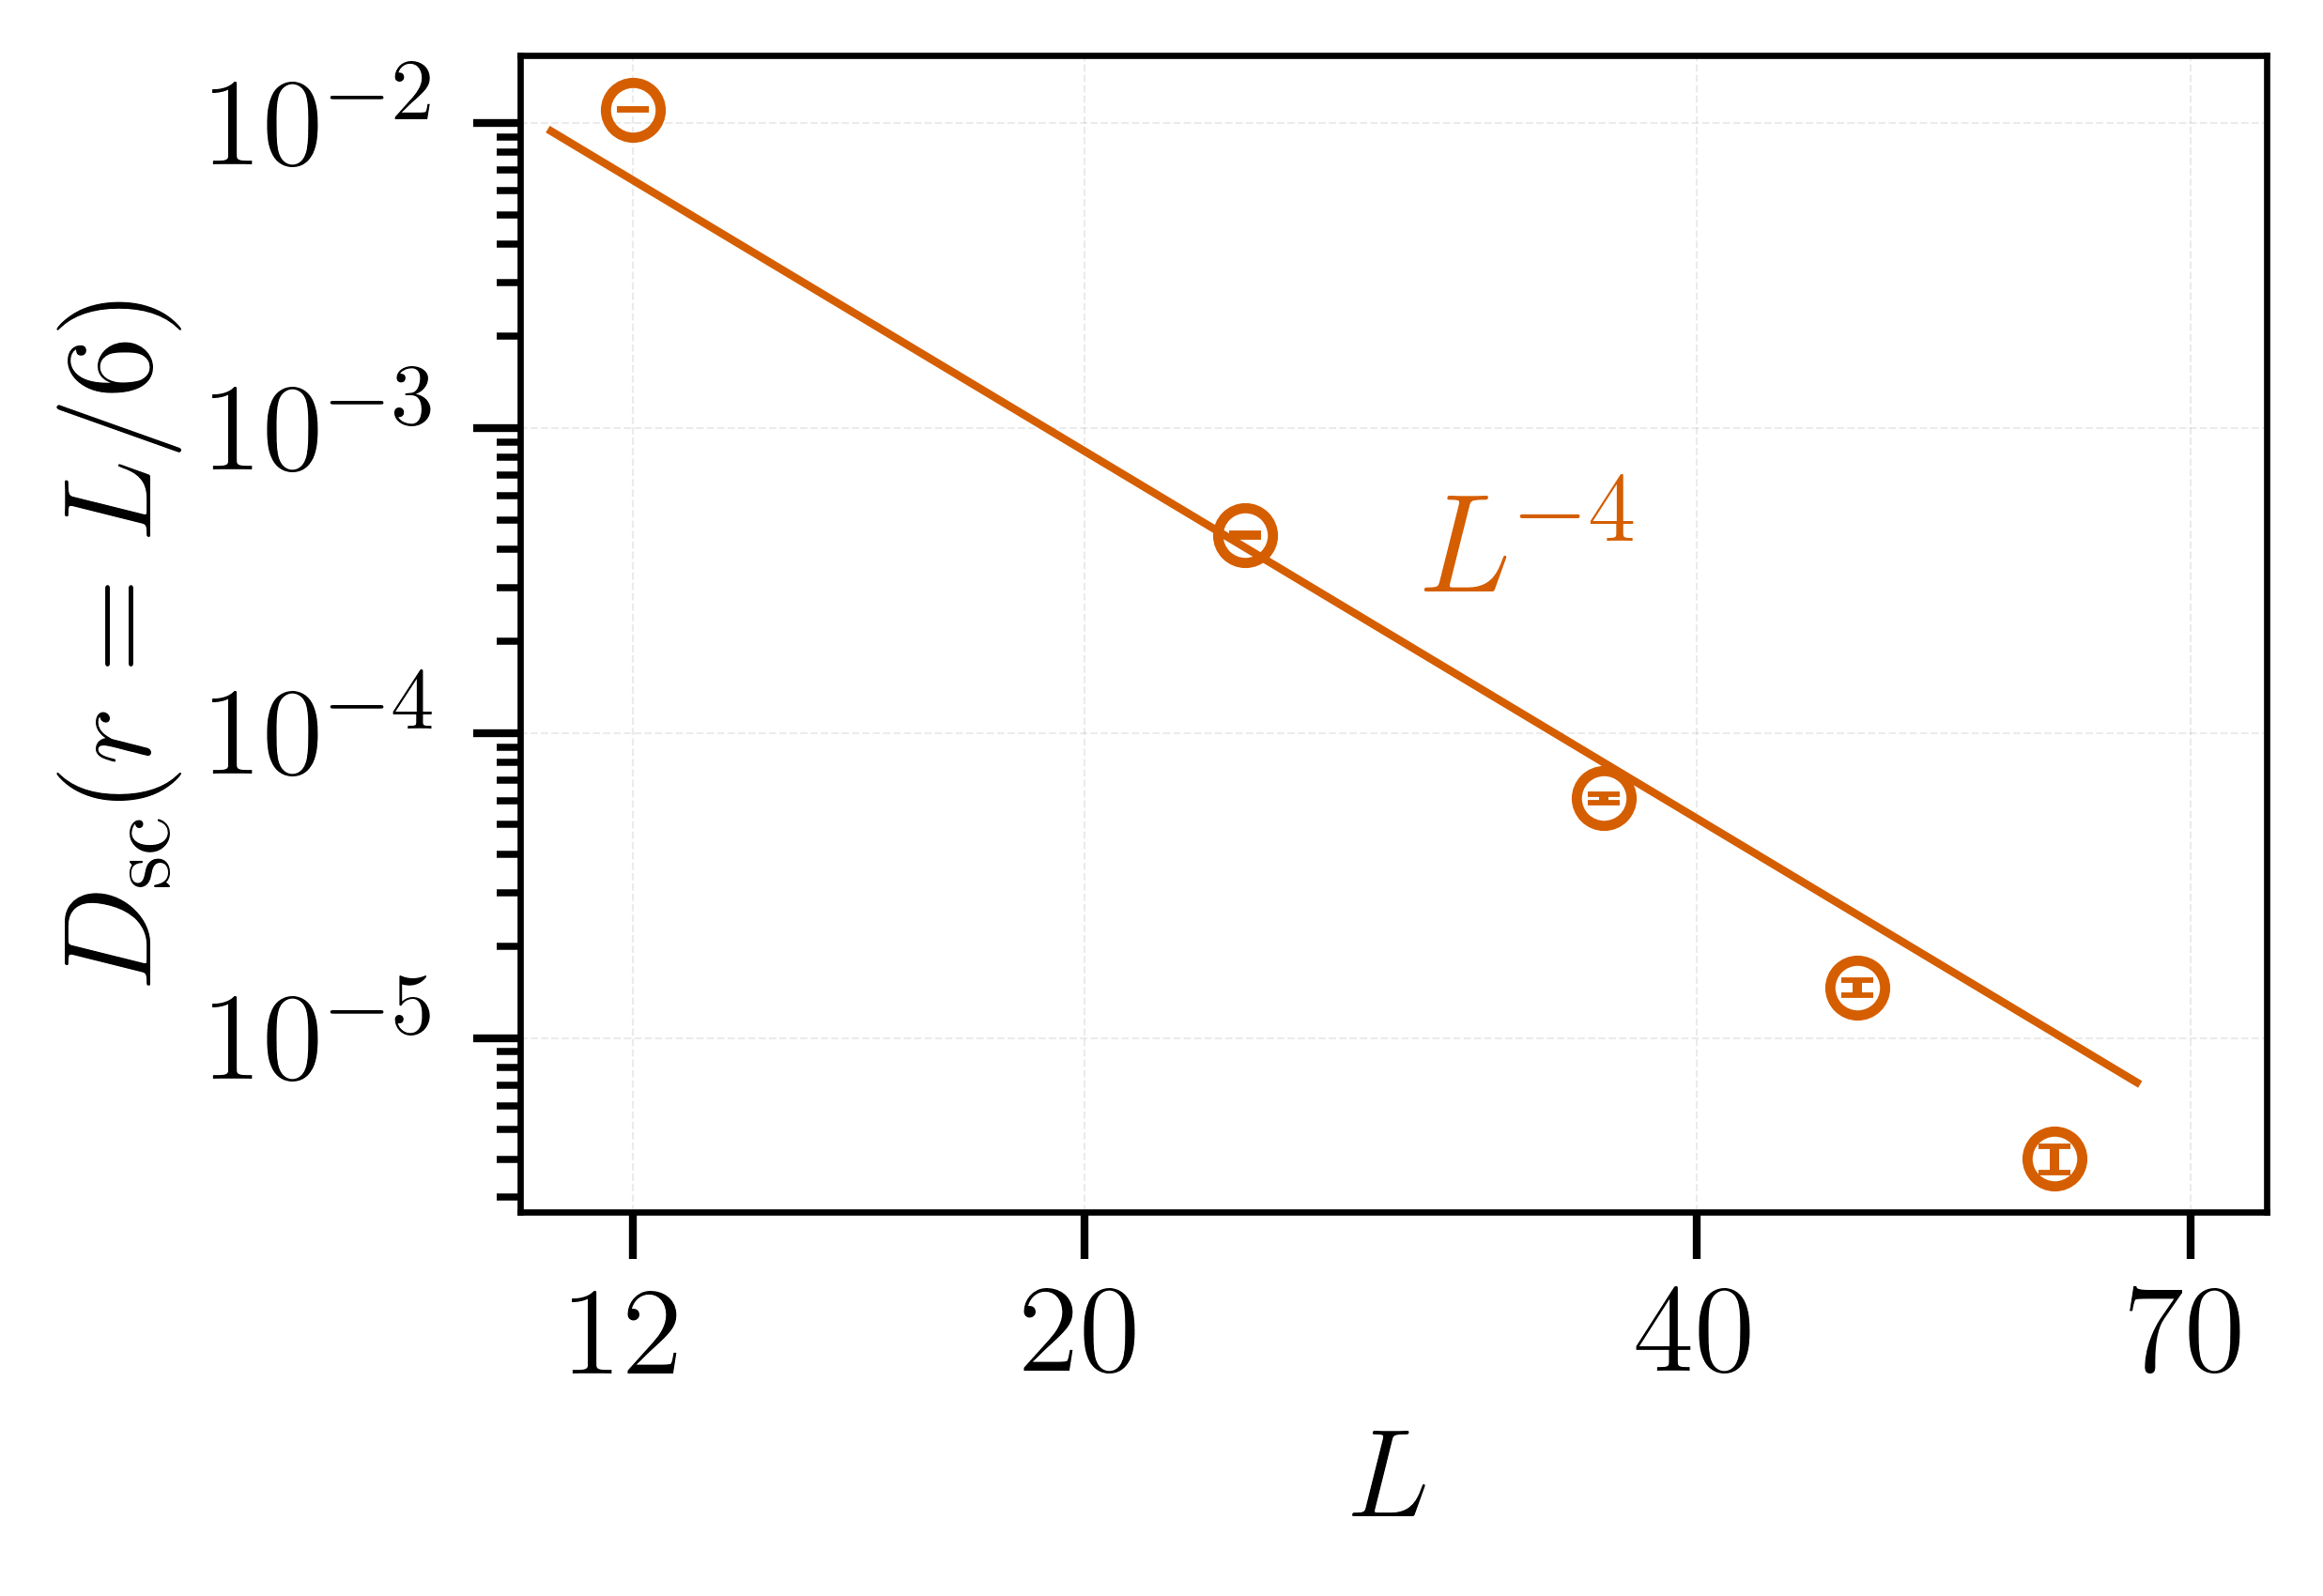

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings 
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

snr_cut = 2

# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------
dsc_color = '#D55E00'   # D_sc

# ---------------------------------------------------------
# ---------------------------------------------------------
def fit_A_fixed_m(L, y, m, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")

    logA_samples = np.log(y) + m * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, Lmin, Lmax, m, frac, y_mult, color,
                                 text, fontsize=ANNOT_FSIZE,
                                 ha='left', va='center'):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-m))
    ax.text(L0, y0 * y_mult, text, fontsize=fontsize, color=color,
            ha=ha, va=va, zorder=6)

def extend_logL_span_for_marker(ax, Lmin, Lmax, markersize_pts, where="both", extra=1.0):

    fig = ax.figure
    fig.canvas.draw()

    r_pix = 0.5 * markersize_pts * fig.dpi / 72.0  

    def delta_log10L_at(L0):
        eps = 0.01
        L1 = L0 * (1.0 + eps)
        x0 = ax.transData.transform((L0, 1.0))[0]
        x1 = ax.transData.transform((L1, 1.0))[0]
        dx = abs(x1 - x0)
        if dx <= 1e-9:
            return 0.01
        dlog10 = abs(np.log10(L1) - np.log10(L0))
        pix_per_log10 = dx / dlog10
        return extra * (r_pix / pix_per_log10)

    logLmin, logLmax = np.log10(Lmin), np.log10(Lmax)
    if where in ("both", "left"):
        logLmin -= delta_log10L_at(Lmin)
    if where in ("both", "right"):
        logLmax += delta_log10L_at(Lmax)

    return 10**logLmin, 10**logLmax

# ============================================================
# ============================================================
def _collect_fixed_fraction_vs_L_single_obs(
    df,
    frac,
    mean_col,
    se_col,
    snr_cut=10.0,
    r_min=2,
    parity=None           
):
    num, den = frac
    L_vals = np.sort(df["L"].unique())

    L_sel_list, y_list, se_list = [], [], []

    for L in L_vals:
        if L % den != 0:
            continue

        r = (num * L) // den
        if r * den != num * L:
            continue

        if parity == "odd" and (r % 2 == 0):
            continue
        if parity == "even" and (r % 2 == 1):
            continue

        if r < r_min:
            continue

        row = df[(df["L"] == L) & (df["r"] == r)]
        if row.empty:
            continue

        mean_val = row[mean_col].values[0]
        se_val   = row[se_col].values[0]

        y_val = ((-1)**r) * mean_val

        if not (np.isfinite(y_val) and np.isfinite(se_val) and y_val > 0 and se_val > 0):
            continue

        snr_val = float(y_val / se_val)
        if not (np.isfinite(snr_val) and snr_val >= snr_cut):
            continue

        L_sel_list.append(L)
        y_list.append(y_val)
        se_list.append(se_val)

    L_arr = np.array(L_sel_list, dtype=float)
    y_arr = np.array(y_list, dtype=float)
    e_arr = np.array(se_list, dtype=float)

    if len(L_arr) > 0:
        order = np.argsort(L_arr)
        L_arr, y_arr, e_arr = L_arr[order], y_arr[order], e_arr[order]

    return L_arr, y_arr, e_arr

def _pick_label_from_frac(frac):
    num, den = frac
    if num == 1:
        return rf"r=L/{den}"
    return rf"r=\frac{{{num}}}{{{den}}}L"

# ============================================================
# ============================================================
def pick_best_L_window_for_fixed_power(L, y, m=4.0, min_points=3):
    L = np.asarray(L, float)
    y = np.asarray(y, float)
    logA = np.log(y) + m * np.log(L)

    n = len(L)
    if n < min_points:
        return 0, n

    best = None
    for i0 in range(0, n - min_points + 1):
        for i1 in range(i0 + min_points, n + 1):
            window = logA[i0:i1]
            score = float(np.std(window))
            length = i1 - i0
            key = (score, -length)  # minimize scatter, prefer longer
            if best is None or key < best[0]:
                best = (key, i0, i1)

    _, i0_best, i1_best = best
    return i0_best, i1_best

# ============================================================
# ============================================================
def plot_Dsc_fixed_frac_reference_style(
    frac_Dsc=(1, 4),
    csv_file=None,
    snr_cut_Dsc=10.0,
    r_min=2,
    title=None,
    L_ticks=(12, 20, 100),
    pdf_name=None,
    debug=False,
    ann_Dsc=(0.22, 0.80, r'$L^{-4}$'),
    fit_min_points=3,
    amplitude_mode="best",      
    line_span="marker_edges",   
    marker_edge_extra=3.0,      
    y_pad_lower=1.55,           
    y_pad_upper=1.30,           
):
    if csv_file is None:
        raise ValueError("csv_file must be provided.")
    df = pd.read_csv(csv_file)

    L_Dsc, y_Dsc, e_Dsc = _collect_fixed_fraction_vs_L_single_obs(
        df, frac=frac_Dsc,
        mean_col="dij_c_mean", se_col="dij_c_se",
        snr_cut=snr_cut_Dsc, r_min=r_min,
        parity="even",
    )

    if debug:
        print("Selected D_sc L:", L_Dsc)

    if len(L_Dsc) == 0:
        raise ValueError("No D_sc points available after cuts (strict r and even r).")

    fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

    msize = 7
    eb = ax.errorbar(
        L_Dsc, y_Dsc, yerr=e_Dsc,
        fmt='o', color=dsc_color, ecolor=dsc_color,
        markersize=msize, markerfacecolor='none',
        capsize=2, elinewidth=1.2, capthick=0.7,
        zorder=3
    )
    eb[0].set_markeredgewidth(1.3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.88 * min(L_ticks), 1.09 * max(L_ticks))

    if amplitude_mode.lower() == "all":
        L_amp, y_amp, e_amp = L_Dsc, y_Dsc, e_Dsc
        if debug:
            print("Amplitude mode: ALL valid points")
    elif amplitude_mode.lower() == "best":
        i0, i1 = pick_best_L_window_for_fixed_power(
            L_Dsc, y_Dsc, m=4.0, min_points=fit_min_points
        )
        L_amp, y_amp, e_amp = L_Dsc[i0:i1], y_Dsc[i0:i1], e_Dsc[i0:i1]
        if debug and len(L_amp) > 0:
            print(f"Amplitude mode: BEST window [{i0}:{i1}] -> L in [{L_amp.min():.0f}, {L_amp.max():.0f}]")
    else:
        raise ValueError("amplitude_mode must be 'all' or 'best'.")

    A_dsc = fit_A_fixed_m(L_amp, y_amp, m=4.0, yerr=e_amp)

    L_line_min = float(L_Dsc.min())
    L_line_max = float(L_Dsc.max())

    if line_span.lower() == "marker_edges":
        Lmin_ext, Lmax_ext = extend_logL_span_for_marker(
            ax, L_line_min, L_line_max, msize, where="both", extra=marker_edge_extra
        )
        L_plot_min, L_plot_max = float(Lmin_ext), float(Lmax_ext)
    elif line_span.lower() == "data":
        L_plot_min, L_plot_max = L_line_min, L_line_max
    else:
        raise ValueError("line_span must be 'marker_edges' or 'data'.")

    L_fit = np.logspace(np.log10(L_plot_min), np.log10(L_plot_max), 600)
    ax.plot(L_fit, A_dsc * L_fit**(-4), color=dsc_color, lw=1.0, zorder=2)

    f, ym, txt = ann_Dsc
    place_scaling_label_near_line(
        ax, A_dsc, L_plot_min, L_plot_max,
        m=4.0, frac=f, y_mult=ym, color=dsc_color, text=txt
    )

    ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
    ax.set_ylabel(rf'$D_{{\mathrm{{sc}}}}({ _pick_label_from_frac(frac_Dsc) })$', fontsize=LABEL_FSIZE)
    if title is not None:
        ax.set_title(title, fontsize=LABEL_FSIZE + 1)

    ax.set_xticks(list(L_ticks))
    ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

    y_endpoints = np.array(
        [A_dsc * (L_plot_min**(-4)), A_dsc * (L_plot_max**(-4))],
        dtype=float
    )
    all_y = np.concatenate([y_Dsc, y_endpoints])
    y_min, y_max = float(np.min(all_y)), float(np.max(all_y))
    ax.set_ylim(y_min / y_pad_lower, y_max * y_pad_upper)

    if pdf_name is not None:
        plt.savefig(
            pdf_name,
            format="pdf",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.08,
            transparent=False
        )
        print(f"Saved high-quality PDF as: {pdf_name}")

    plt.show()
    return fig, ax

# ============================================================
# ============================================================
csv_file = "heis_sdrg.csv"

fig, ax = plot_Dsc_fixed_frac_reference_style(
    frac_Dsc=(1, 6),
    csv_file=csv_file,
    snr_cut_Dsc=10,
    r_min=2,
    L_ticks=(12, 20, 40, 70),
    debug=True,
    ann_Dsc=(0.55, 2.1, r'$L^{-4}$'),
    amplitude_mode="best",       
    line_span="marker_edges",   
    marker_edge_extra=3.0,      
    y_pad_lower=1.5,            
    y_pad_upper=1.5,         
    pdf_name="Figs/AFM-Heisenberg-SDRG-D-sc.pdf"
)

# Fig.5 - Supplemental Material

## Fig.5(a)

=== sij ===
 n points used: 279
 Cuts: SNR>=5.0, L>=20, r<=40
 C = 256 ± 11.5
 a = 0.460 ± 0.012
 b = 1.028 ± 0.006
 RMSE(logSNR) = 0.0675
 R^2(logSNR)  = 0.9905

Requested R_PLOT: [5, 7, 11, 15] -> using (sorted): [5, 7, 11, 15]
Requested L_PLOT: [28, 40, 60, 100] -> using (sorted): [28, 40, 60, 100]

Saved high-quality PDF as: Figs/SNR_spincorr_AFMHeisenberg.pdf


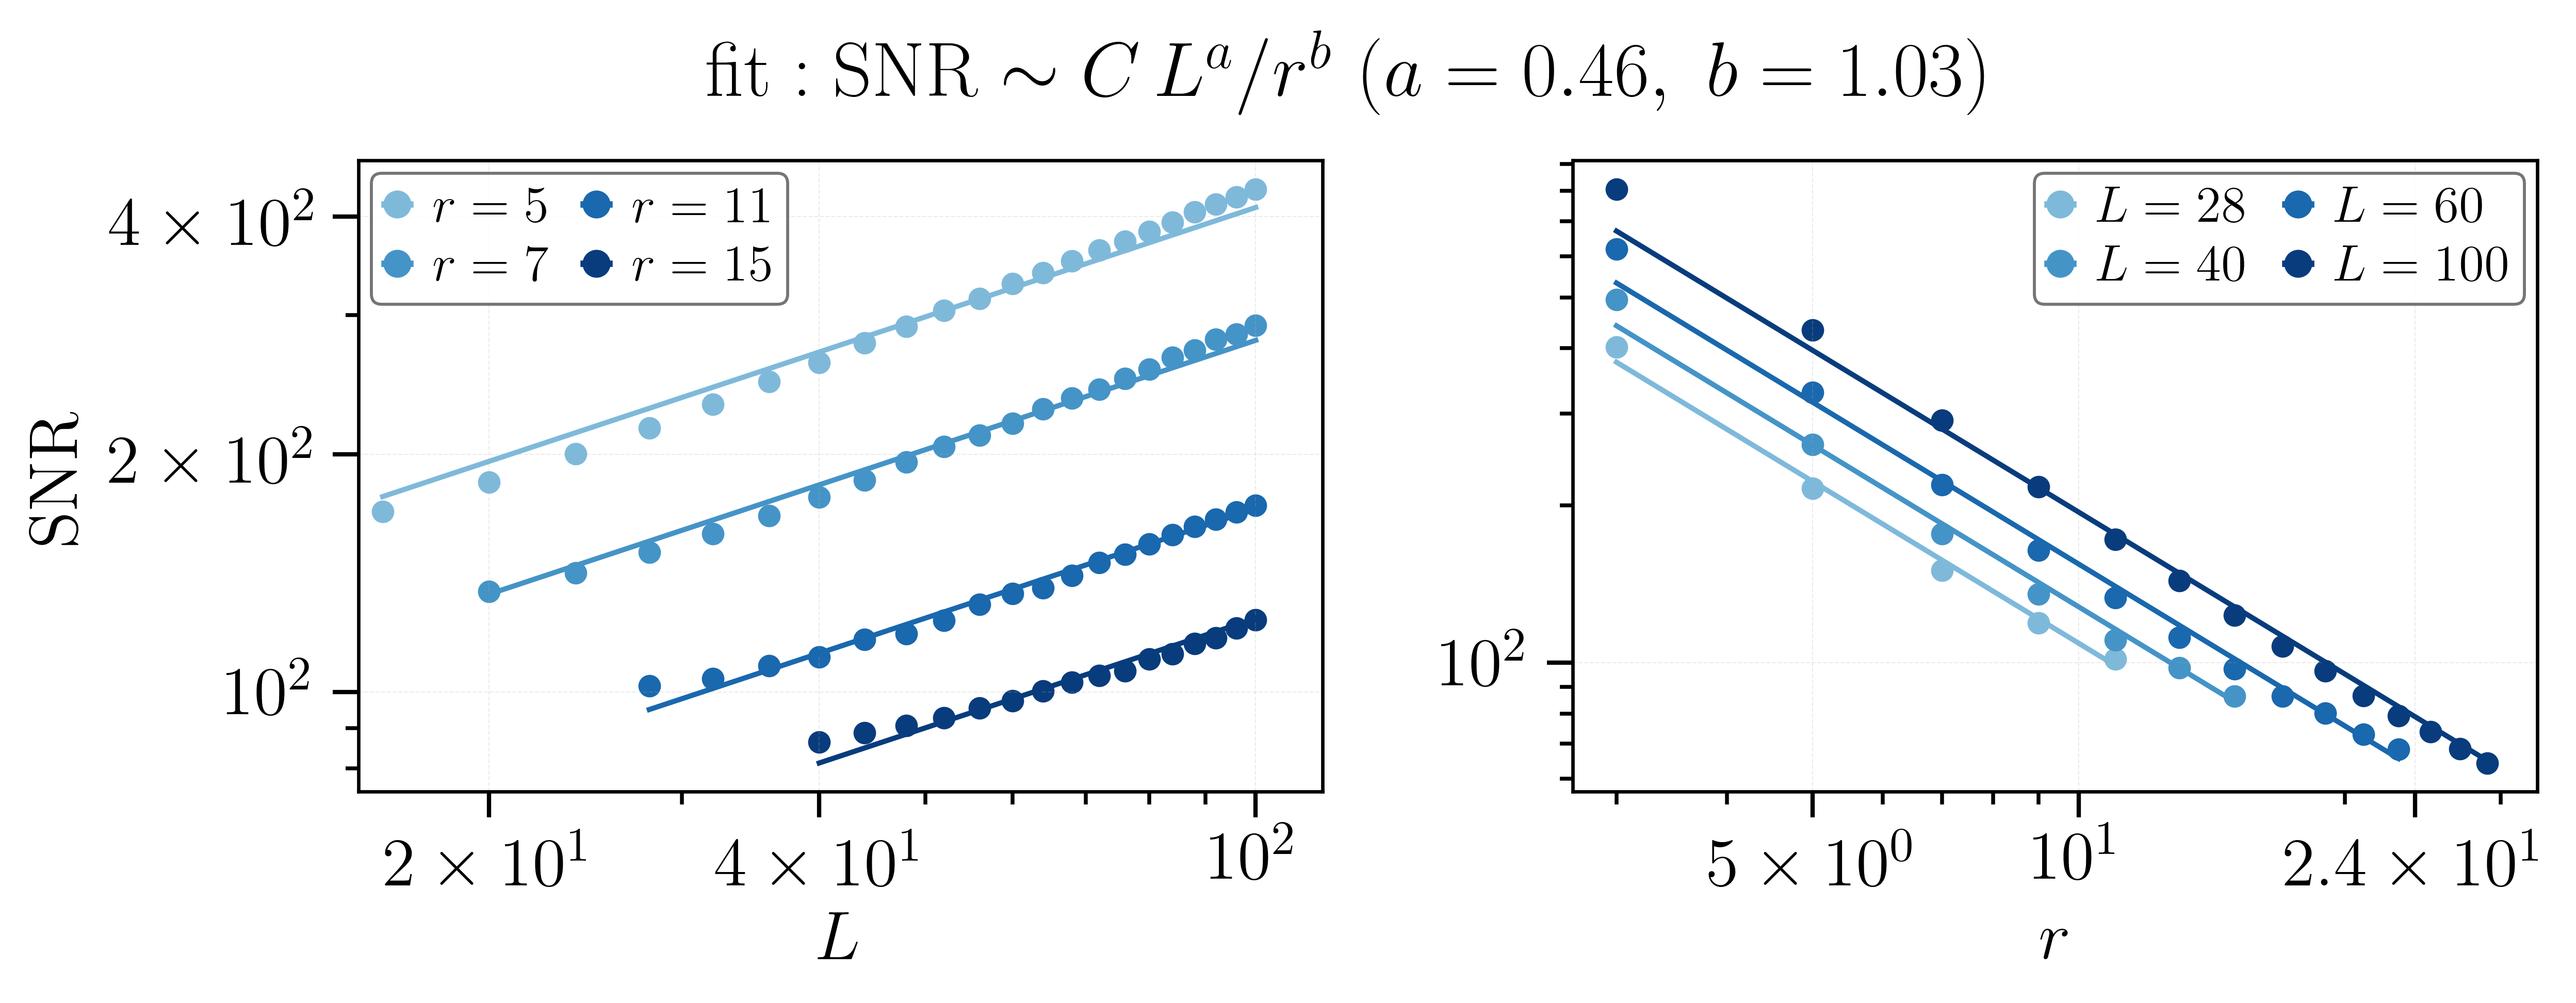

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter, FixedLocator, NullLocator, FuncFormatter, NullFormatter,LogLocator

def sci_fmt(x, pos):
    if x == 0:
        return "0"

    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / (10**exp)

    if np.isclose(coeff, 1):
        return rf"$10^{{{exp}}}$"
    else:
        if float(coeff).is_integer():
            coeff = int(coeff)
        return rf"${coeff}\times 10^{{{exp}}}$"
# =============================================================
# =============================================================
csv_file = "heis_sdrg.csv"
snr_col  = "sij_snr"
snr_cut_for_fit = 5.0


FIT_MIN_L = 20
FIT_MAX_L = None
FIT_MIN_R = 3
FIT_MAX_R = 40
FIT_R_MAX_FRAC = None    


PLOT_MIN_L = 16
PLOT_MAX_L = None
PLOT_MIN_R = None
PLOT_MAX_R = None
R_MAX_FRAC = 0.4         

R_PLOT_DESIRED = [5, 7, 11, 15]
L_PLOT_DESIRED = [28, 40, 60, 100]


R_MAX_RIGHT = 30

# =============================================================
# Matplotlib / LaTeX settings 
# =============================================================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ROUND_AB     = 2
MARKER_S     = 18

CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Blues

# =============================================================
# =============================================================
def fit_snr_scaling_L_over_r(
    df,
    snr_col,
    snr_cut=10.0,
    min_r=None,
    max_r=None,
    min_L=40,
    max_L=None,
    r_max_frac=None,
):
    snr = df[snr_col].to_numpy(dtype=float)
    r   = df["r"].to_numpy(dtype=float)
    L   = df["L"].to_numpy(dtype=float)

    mask = np.isfinite(snr) & np.isfinite(r) & np.isfinite(L)
    mask &= (snr > 0) & (snr >= snr_cut)

    if min_r is not None:
        mask &= (r >= float(min_r))
    if max_r is not None:
        mask &= (r <= float(max_r))
    if min_L is not None:
        mask &= (L >= float(min_L))
    if max_L is not None:
        mask &= (L <= float(max_L))

    if r_max_frac is not None:
        mask &= (r <= float(r_max_frac) * L)

    r_fit   = r[mask]
    L_fit   = L[mask]
    snr_fit = snr[mask]

    n = len(snr_fit)
    if n < 3:
        raise ValueError(f"Not enough data points ({n}) after cuts to fit 3 parameters.")

    log_r   = np.log(r_fit)
    log_L   = np.log(L_fit)
    log_snr = np.log(snr_fit)

    X = np.column_stack([
        np.ones_like(log_L),
        log_L,
        -log_r,
    ])

    beta, residuals, rank, svals = np.linalg.lstsq(X, log_snr, rcond=None)
    logC, a, b = beta

    log_snr_hat = X @ beta
    resid = log_snr - log_snr_hat

    rmse_logsnr = float(np.sqrt(np.mean(resid**2)))

    y = log_snr
    ybar = float(np.mean(y))
    sse = float(np.sum((y - log_snr_hat)**2))
    sst = float(np.sum((y - ybar)**2))
    r2_logsnr = float(1.0 - sse / sst) if sst > 0 else float("nan")

    if residuals.size > 0:
        rss = float(residuals[0])
        dof = n - X.shape[1]
        sigma2 = rss / dof
    else:
        sigma2 = 0.0

    XtX_inv = np.linalg.inv(X.T @ X)
    cov_beta = sigma2 * XtX_inv

    sigma_logC = float(np.sqrt(cov_beta[0, 0]))
    sigma_a    = float(np.sqrt(cov_beta[1, 1]))
    sigma_b    = float(np.sqrt(cov_beta[2, 2]))

    C = float(np.exp(logC))
    sigma_C = float(C * sigma_logC)

    return {
        "C": C, "a": float(a), "b": float(b),
        "sigma_C": sigma_C, "sigma_a": sigma_a, "sigma_b": sigma_b,
        "n_points": int(n),
        "mask": mask,
        "rmse_logsnr": rmse_logsnr,
        "r2_logsnr": r2_logsnr,
    }

# =============================================================
# =============================================================
def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

def color_map_monotone(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = sorted([int(v) for v in values])
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * ts
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

def pick_existing_or_nearest(desired_list, available_list, k=4):
    avail = np.array(sorted(set(int(x) for x in available_list)), dtype=int)
    if avail.size == 0:
        return []
    used, chosen = set(), []

    for d in desired_list:
        d = int(d)
        if d in avail and d not in used:
            chosen.append(d); used.add(d)

    for d in desired_list:
        if len(chosen) >= k:
            break
        d = int(d)
        if d in used:
            continue
        v = int(avail[np.argmin(np.abs(avail - d))])
        if v not in used:
            chosen.append(v); used.add(v)

    if len(chosen) < k:
        rem = [int(x) for x in avail.tolist() if int(x) not in used]
        if rem:
            rem = np.array(rem, dtype=int)
            m = min(k - len(chosen), rem.size)
            idxs = np.linspace(0, rem.size - 1, m).round().astype(int)
            for v in rem[idxs]:
                v = int(v)
                if v not in used and len(chosen) < k:
                    chosen.append(v); used.add(v)

    return sorted(chosen[:k])

# =============================================================
# =============================================================
df = pd.read_csv(csv_file)
required = {"L", "r", snr_col}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing columns in CSV: {sorted(missing)}")

df = df.copy()
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["r"] = pd.to_numeric(df["r"], errors="coerce")
df[snr_col] = pd.to_numeric(df[snr_col], errors="coerce")

# =============================================================
# =============================================================
res = fit_snr_scaling_L_over_r(
    df, snr_col,
    snr_cut=snr_cut_for_fit,
    min_r=FIT_MIN_R, max_r=FIT_MAX_R,
    min_L=FIT_MIN_L, max_L=FIT_MAX_L,
    r_max_frac=FIT_R_MAX_FRAC
)

a = float(res["a"])
b = float(res["b"])
C = float(res["C"])

print("=== sij ===")
print(f" n points used: {res['n_points']}")
print(f" Cuts: SNR>={snr_cut_for_fit}, L>={FIT_MIN_L}, r<={FIT_MAX_R}")
print(f" C = {C:.3g} ± {res['sigma_C']:.3g}")
print(f" a = {a:.3f} ± {res['sigma_a']:.3f}")
print(f" b = {b:.3f} ± {res['sigma_b']:.3f}")
print(f" RMSE(logSNR) = {res['rmse_logsnr']:.4f}")
print(f" R^2(logSNR)  = {res['r2_logsnr']:.4f}")
print()

# =============================================================
# =============================================================
L_all = df["L"].to_numpy(dtype=float)
r_all = df["r"].to_numpy(dtype=float)
snr_all = df[snr_col].to_numpy(dtype=float)

plot_mask = np.isfinite(L_all) & np.isfinite(r_all) & np.isfinite(snr_all)
plot_mask &= (snr_all > 0) & (snr_all >= snr_cut_for_fit)

if PLOT_MIN_L is not None:
    plot_mask &= (L_all >= float(PLOT_MIN_L))
if PLOT_MAX_L is not None:
    plot_mask &= (L_all <= float(PLOT_MAX_L))
if PLOT_MIN_R is not None:
    plot_mask &= (r_all >= float(PLOT_MIN_R))
if PLOT_MAX_R is not None:
    plot_mask &= (r_all <= float(PLOT_MAX_R))

if R_MAX_FRAC is not None:
    plot_mask &= (r_all <= float(R_MAX_FRAC) * L_all)

df_plot = df.loc[plot_mask, ["L", "r", snr_col]].dropna().copy()
if df_plot.empty:
    raise RuntimeError("No points survived plot_mask. Relax PLOT cuts / R_MAX_FRAC.")

df_plot["Li"] = df_plot["L"].round().astype(int)
df_plot["ri"] = df_plot["r"].round().astype(int)

if R_MAX_RIGHT is not None:
    df_plot_right = df_plot[df_plot["ri"] <= int(R_MAX_RIGHT)].copy()
else:
    df_plot_right = df_plot.copy()

avail_r = sorted(df_plot["ri"].unique().tolist())
avail_L_right = sorted(df_plot_right["Li"].unique().tolist())

R_PLOT_USE = pick_existing_or_nearest(R_PLOT_DESIRED, avail_r, k=4)
L_PLOT_USE = pick_existing_or_nearest(L_PLOT_DESIRED, avail_L_right, k=4)

print(f"Requested R_PLOT: {R_PLOT_DESIRED} -> using (sorted): {R_PLOT_USE}")
print(f"Requested L_PLOT: {L_PLOT_DESIRED} -> using (sorted): {L_PLOT_USE}")
print()

color_by_r = color_map_monotone(R_PLOT_USE)
color_by_L = color_map_monotone(L_PLOT_USE)

# =============================================================
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

def _sci_major_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    mant_r = int(round(mant))

    if exp == 0:
        return rf"${int(round(x))}$"

    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

# -------------------------
# -------------------------
_left_L_all = []
_left_snr_all = []

for r0 in R_PLOT_USE:
    sub = df_plot[df_plot["ri"] == int(r0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("L")
    Ls = sub["L"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _left_L_all.append(Ls)
    _left_snr_all.append(sn)

    col = color_by_r[int(r0)]
    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)

    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$")

if _left_L_all:
    Lmin = float(np.min(np.concatenate(_left_L_all)))
    Lmax = float(np.max(np.concatenate(_left_L_all)))
    ax1.set_xlim(left=Lmin * 0.95, right=Lmax * 1.15)

    ax1.set_xticks([20, 40, 100])
    ax1.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax1.xaxis.set_minor_formatter(NullFormatter())

if _left_snr_all:
    y_min = float(np.min(np.concatenate(_left_snr_all)))
    y_max = float(np.max(np.concatenate(_left_snr_all)))
    cand = [1e2, 2e2, 4e2, 5e2, 1e3, 2e3, 5e3, 1e4]
    lo = y_min / 1.05
    hi = y_max * 1.05
    yticks = [t for t in cand if (t >= lo and t <= hi)]
    if 1e2 not in yticks:
        yticks = [1e2] + yticks
    yticks = sorted(set(yticks))
    ax1.set_yticks(yticks)
    ax1.yaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax1.yaxis.set_minor_formatter(NullFormatter())

r_handles = []
for r0 in R_PLOT_USE:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# -------------------------
# Right panel
# -------------------------
_right_r_all = []
_right_snr_all = []

for L0 in L_PLOT_USE:
    sub = df_plot_right[df_plot_right["Li"] == int(L0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("r")
    rs = sub["r"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _right_r_all.append(rs)
    _right_snr_all.append(sn)

    col = color_by_L[int(L0)]
    c0_slice = fit_c0_fixed_L(rs, sn, L0, a, b)

    r_fit = np.logspace(np.log10(rs.min()), np.log10(rs.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b)

    ax2.scatter(rs, sn, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"")

if _right_r_all:
    left_now = ax2.get_xlim()[0]
    if R_MAX_RIGHT is not None:
        r_right = float(R_MAX_RIGHT)
        ax2.set_xlim(left=left_now, right=r_right * 1.1)
    else:
        r_max = float(np.max(np.concatenate(_right_r_all)))
        ax2.set_xlim(left=left_now, right=r_max * 1.1)

    ax2.set_xticks([5, 10, 30])
    ax2.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax2.xaxis.set_minor_formatter(NullFormatter())


if _right_snr_all:
    y_min = float(np.min(np.concatenate(_right_snr_all)))
    y0, y1 = ax2.get_ylim()
    ax2.set_ylim(bottom=min(y0, y_min * 0.92), top=y1)
    
ax2.xaxis.set_major_locator(FixedLocator([5,10,24]))
ax2.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax2.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1))
ax2.xaxis.set_minor_formatter(NullFormatter())
L_handles = []
for L0 in L_PLOT_USE:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

a_leg = round(a, int(ROUND_AB))
b_leg = round(b, int(ROUND_AB))
fig.suptitle(
    rf"$\mathrm{{fit}}:\mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$  ($a={a_leg},\ b={b_leg}$)",
    fontsize=18, y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.26)

pdf_name = "Figs/SNR_spincorr_AFMHeisenberg.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

## Fig.5(b)

=== dij_c ===
 n points used: 178
 Cuts: SNR>=5, L>=20, r<=40
 C = 541 ± 45.1
 a = 0.518 ± 0.019
 b = 2.783 ± 0.022
 RMSE(logSNR) = 0.1166
 R^2(logSNR)  = 0.9896

Requested R_PLOT: [3, 5, 7, 9] -> using (sorted): [3, 5, 7, 9]
Requested L_PLOT: [16, 32, 60, 100] -> using (sorted): [16, 32, 60, 100]

Saved high-quality PDF as: Figs/SNR_fm_AFMHeisenberg.pdf


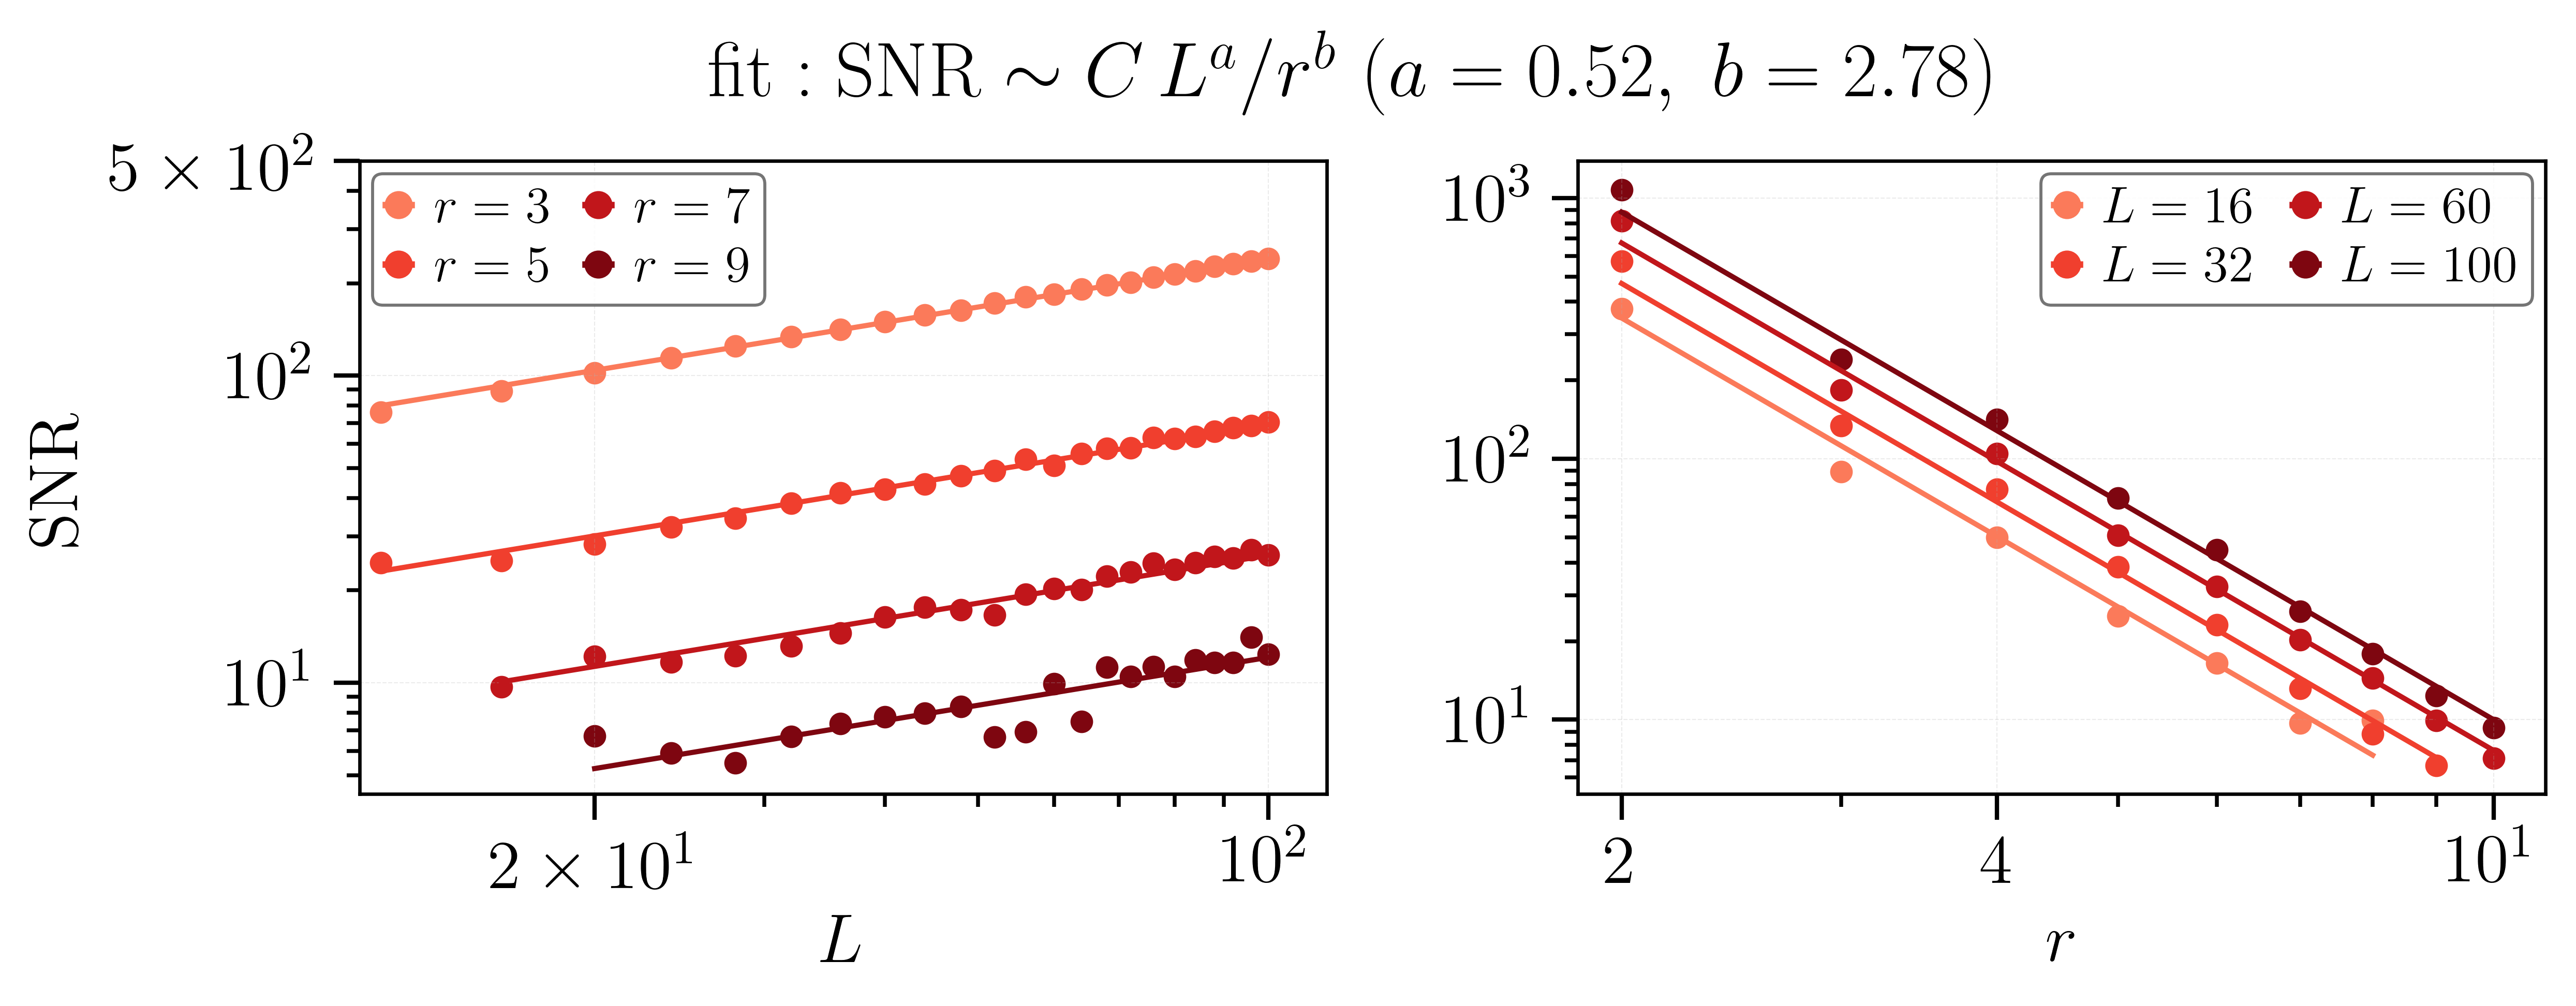

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter, NullLocator, FuncFormatter, NullFormatter


csv_file = "heis_sdrg.csv"
snr_col  = "ddij_snr"
snr_cut_for_fit = 5


FIT_MIN_L = 20
FIT_MAX_L = 100
FIT_MIN_R = 3
FIT_MAX_R = 40
FIT_R_MAX_FRAC = None

PLOT_MIN_L = 12
PLOT_MAX_L = None
PLOT_MIN_R = None
PLOT_MAX_R = None
R_MAX_FRAC = None

R_PLOT_DESIRED = [3, 5, 7, 9]
L_PLOT_DESIRED = [16, 32, 60, 100]

R_MAX_RIGHT = 10


L_SAMPLE_RULES = [
    (50, 1),
    (100, 2),
]

# =============================================================
# Matplotlib / LaTeX settings
# =============================================================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ROUND_AB     = 2
MARKER_S     = 18

CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Reds

# =============================================================
# =============================================================
def tex_escape(s: str) -> str:
    return (s.replace("\\", r"\textbackslash{}")
             .replace("_", r"\_")
             .replace("%", r"\%")
             .replace("&", r"\&")
             .replace("#", r"\#")
             .replace("{", r"\{")
             .replace("}", r"\}")
             .replace("^", r"\^{}")
             .replace("~", r"\~{}"))

snr_col_tex = tex_escape(snr_col)

# =============================================================
# =============================================================
def fit_snr_scaling_L_over_r(
    df,
    snr_col,
    snr_cut=10.0,
    min_r=None,
    max_r=None,
    min_L=40,
    max_L=None,
    r_max_frac=None,
):
    snr = df[snr_col].to_numpy(dtype=float)
    r   = df["r"].to_numpy(dtype=float)
    L   = df["L"].to_numpy(dtype=float)

    mask = np.isfinite(snr) & np.isfinite(r) & np.isfinite(L)
    mask &= (snr > 0) & (snr >= snr_cut)

    if min_r is not None:
        mask &= (r >= float(min_r))
    if max_r is not None:
        mask &= (r <= float(max_r))
    if min_L is not None:
        mask &= (L >= float(min_L))
    if max_L is not None:
        mask &= (L <= float(max_L))

    if r_max_frac is not None:
        mask &= (r <= float(r_max_frac) * L)

    r_fit   = r[mask]
    L_fit   = L[mask]
    snr_fit = snr[mask]

    n = len(snr_fit)
    if n < 3:
        raise ValueError(f"Not enough data points ({n}) after cuts to fit 3 parameters.")

    log_r   = np.log(r_fit)
    log_L   = np.log(L_fit)
    log_snr = np.log(snr_fit)

    X = np.column_stack([
        np.ones_like(log_L),
        log_L,
        -log_r,
    ])

    beta, residuals, rank, svals = np.linalg.lstsq(X, log_snr, rcond=None)
    logC, a, b = beta

    log_snr_hat = X @ beta
    resid = log_snr - log_snr_hat

    rmse_logsnr = float(np.sqrt(np.mean(resid**2)))

    y = log_snr
    ybar = float(np.mean(y))
    sse = float(np.sum((y - log_snr_hat)**2))
    sst = float(np.sum((y - ybar)**2))
    r2_logsnr = float(1.0 - sse / sst) if sst > 0 else float("nan")

    if residuals.size > 0:
        rss = float(residuals[0])
        dof = n - X.shape[1]
        sigma2 = rss / dof
    else:
        sigma2 = 0.0

    XtX_inv = np.linalg.inv(X.T @ X)
    cov_beta = sigma2 * XtX_inv

    sigma_logC = float(np.sqrt(cov_beta[0, 0]))
    sigma_a    = float(np.sqrt(cov_beta[1, 1]))
    sigma_b    = float(np.sqrt(cov_beta[2, 2]))

    C = float(np.exp(logC))
    sigma_C = float(C * sigma_logC)

    return {
        "C": C, "a": float(a), "b": float(b),
        "sigma_C": sigma_C, "sigma_a": sigma_a, "sigma_b": sigma_b,
        "n_points": int(n),
        "mask": mask,
        "rmse_logsnr": rmse_logsnr,
        "r2_logsnr": r2_logsnr,
    }

# =============================================================
# =============================================================
def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

def color_map_monotone(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = sorted([int(v) for v in values])
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * ts
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

def pick_existing_or_nearest(desired_list, available_list, k=4):
    avail = np.array(sorted(set(int(x) for x in available_list)), dtype=int)
    if avail.size == 0:
        return []
    used, chosen = set(), []

    for d in desired_list:
        d = int(d)
        if d in avail and d not in used:
            chosen.append(d); used.add(d)

    for d in desired_list:
        if len(chosen) >= k:
            break
        d = int(d)
        if d in used:
            continue
        v = int(avail[np.argmin(np.abs(avail - d))])
        if v not in used:
            chosen.append(v); used.add(v)

    if len(chosen) < k:
        rem = [int(x) for x in avail.tolist() if int(x) not in used]
        if rem:
            rem = np.array(rem, dtype=int)
            m = min(k - len(chosen), rem.size)
            idxs = np.linspace(0, rem.size - 1, m).round().astype(int)
            for v in rem[idxs]:
                v = int(v)
                if v not in used and len(chosen) < k:
                    chosen.append(v); used.add(v)

    return sorted(chosen[:k])

def subsample_fixed_r_by_L_rules(sub: pd.DataFrame, rules, L_col_int="Li"):
    """
    Keep a non-uniform subset of L values according to rules, plus endpoints.
    Uses integer L_col_int (rounded/cleaned L). Returns a filtered copy.
    """
    if sub.empty:
        return sub

    Li = sub[L_col_int].to_numpy(dtype=int)
    keep = np.zeros(Li.shape, dtype=bool)


    for Lmax, step in rules:
        Lmax = int(Lmax)
        step = int(step)
        keep |= ((Li <= Lmax) & (Li % step == 0))

    i_min = int(np.argmin(Li))
    i_max = int(np.argmax(Li))
    keep[i_min] = True
    keep[i_max] = True

    if not np.any(keep):
        return sub.copy()

    return sub.loc[keep].copy()

# =============================================================
# =============================================================
df = pd.read_csv(csv_file)
required = {"L", "r", snr_col}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing columns in CSV: {sorted(missing)}")

df = df.copy()
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["r"] = pd.to_numeric(df["r"], errors="coerce")
df[snr_col] = pd.to_numeric(df[snr_col], errors="coerce")

# =============================================================
# =============================================================
res = fit_snr_scaling_L_over_r(
    df, snr_col,
    snr_cut=snr_cut_for_fit,
    min_r=FIT_MIN_R, max_r=FIT_MAX_R,
    min_L=FIT_MIN_L, max_L=FIT_MAX_L,
    r_max_frac=FIT_R_MAX_FRAC
)

a = float(res["a"])
b = float(res["b"])
C = float(res["C"])

print("=== dij_c ===")
print(f" n points used: {res['n_points']}")
print(f" Cuts: SNR>={snr_cut_for_fit}, L>={FIT_MIN_L}, r<={FIT_MAX_R}")
print(f" C = {C:.3g} ± {res['sigma_C']:.3g}")
print(f" a = {a:.3f} ± {res['sigma_a']:.3f}")
print(f" b = {b:.3f} ± {res['sigma_b']:.3f}")
print(f" RMSE(logSNR) = {res['rmse_logsnr']:.4f}")
print(f" R^2(logSNR)  = {res['r2_logsnr']:.4f}")
print()

# =============================================================
# =============================================================
L_all = df["L"].to_numpy(dtype=float)
r_all = df["r"].to_numpy(dtype=float)
snr_all = df[snr_col].to_numpy(dtype=float)

plot_mask = np.isfinite(L_all) & np.isfinite(r_all) & np.isfinite(snr_all)
plot_mask &= (snr_all > 0) & (snr_all >= snr_cut_for_fit)

if PLOT_MIN_L is not None:
    plot_mask &= (L_all >= float(PLOT_MIN_L))
if PLOT_MAX_L is not None:
    plot_mask &= (L_all <= float(PLOT_MAX_L))
if PLOT_MIN_R is not None:
    plot_mask &= (r_all >= float(PLOT_MIN_R))
if PLOT_MAX_R is not None:
    plot_mask &= (r_all <= float(PLOT_MAX_R))

if R_MAX_FRAC is not None:
    plot_mask &= (r_all <= float(R_MAX_FRAC) * L_all)

df_plot = df.loc[plot_mask, ["L", "r", snr_col]].dropna().copy()
if df_plot.empty:
    raise RuntimeError("No points survived plot_mask. Relax PLOT cuts / R_MAX_FRAC.")


df_plot["Li"] = np.rint(df_plot["L"].to_numpy(dtype=float)).astype(int)
df_plot["ri"] = np.rint(df_plot["r"].to_numpy(dtype=float)).astype(int)

if R_MAX_RIGHT is not None:
    df_plot_right = df_plot[df_plot["ri"] <= int(R_MAX_RIGHT)].copy()
else:
    df_plot_right = df_plot.copy()

avail_r = sorted(df_plot["ri"].unique().tolist())
avail_L_right = sorted(df_plot_right["Li"].unique().tolist())

R_PLOT_USE = pick_existing_or_nearest(R_PLOT_DESIRED, avail_r, k=4)
L_PLOT_USE = pick_existing_or_nearest(L_PLOT_DESIRED, avail_L_right, k=4)

print(f"Requested R_PLOT: {R_PLOT_DESIRED} -> using (sorted): {R_PLOT_USE}")
print(f"Requested L_PLOT: {L_PLOT_DESIRED} -> using (sorted): {L_PLOT_USE}")
print()

color_by_r = color_map_monotone(R_PLOT_USE)
color_by_L = color_map_monotone(L_PLOT_USE)

# =============================================================
# Plot
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

def _sci_major_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    mant_r = int(round(mant))

    if exp == 0:
        return rf"${int(round(x))}$"

    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

# -------------------------
# Left panel
# -------------------------
_left_L_all = []
_left_snr_all = []

for r0 in R_PLOT_USE:
    sub = df_plot[df_plot["ri"] == int(r0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("Li")
    sub = subsample_fixed_r_by_L_rules(sub, L_SAMPLE_RULES, L_col_int="Li")

    Ls = sub["L"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _left_L_all.append(Ls)
    _left_snr_all.append(sn)

    col = color_by_r[int(r0)]
    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)

    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax1, xlabel=r"$L$", ylabel=rf"$\mathrm{{SNR}}$")

if _left_L_all:
    Lmin = float(np.min(np.concatenate(_left_L_all)))
    Lmax = float(np.max(np.concatenate(_left_L_all)))
    ax1.set_xlim(left=Lmin * 0.95, right=Lmax * 1.15)

    ax1.set_xticks([20,100])
    ax1.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax1.xaxis.set_minor_formatter(NullFormatter())

ax1.set_yticks([1e1, 1e2, 5e2])
ax1.yaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
ax1.yaxis.set_minor_formatter(NullFormatter())

r_handles = []
for r0 in R_PLOT_USE:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# -------------------------
# Right panel 
# -------------------------
_right_r_all = []
_right_snr_all = []

for L0 in L_PLOT_USE:
    sub = df_plot_right[df_plot_right["Li"] == int(L0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("r")
    rs = sub["r"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _right_r_all.append(rs)
    _right_snr_all.append(sn)

    col = color_by_L[int(L0)]
    c0_slice = fit_c0_fixed_L(rs, sn, L0, a, b)

    r_fit = np.logspace(np.log10(rs.min()), np.log10(rs.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b)

    ax2.scatter(rs, sn, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax2, xlabel=r"$r$", ylabel=rf"")

if _right_r_all:
    left_now = ax2.get_xlim()[0]
    if R_MAX_RIGHT is not None:
        r_right = float(R_MAX_RIGHT)
        ax2.set_xlim(left=left_now, right=r_right * 1.1)
    else:
        r_max = float(np.max(np.concatenate(_right_r_all)))
        ax2.set_xlim(left=left_now, right=r_max * 1.1)

    ax2.set_xticks([2, 4, 10])
    ax2.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax2.xaxis.set_minor_formatter(NullFormatter())

if _right_snr_all:
    y_min = float(np.min(np.concatenate(_right_snr_all)))
    y0, y1 = ax2.get_ylim()
    ax2.set_ylim(bottom=min(y0, y_min * 0.92), top=y1)

L_handles = []
for L0 in L_PLOT_USE:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

a_leg = round(a, int(ROUND_AB))
b_leg = round(b, int(ROUND_AB))
fig.suptitle(
    rf"$\mathrm{{fit}}:\mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$ ($a={a_leg},\ b={b_leg}$)",
    fontsize=18, y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.26)

pdf_name = "Figs/SNR_fm_AFMHeisenberg.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

## Fig.5(c)

=== dij_c === 
 n points used: 100
 Cuts: SNR>=5, L>=20, r<=40
 C = 539 ± 33.2
 a = 0.509 ± 0.014
 b = 2.622 ± 0.016
 RMSE(logSNR) = 0.0604
 R^2(logSNR)  = 0.9964

Requested R_PLOT: [4, 6, 8, 10] -> using (sorted): [4, 6, 8, 10]
Requested L_PLOT: [24, 40, 60, 100] -> using (sorted): [24, 40, 60, 100]

Saved high-quality PDF as: Figs/SNR_sc_AFMHeisenberg.pdf


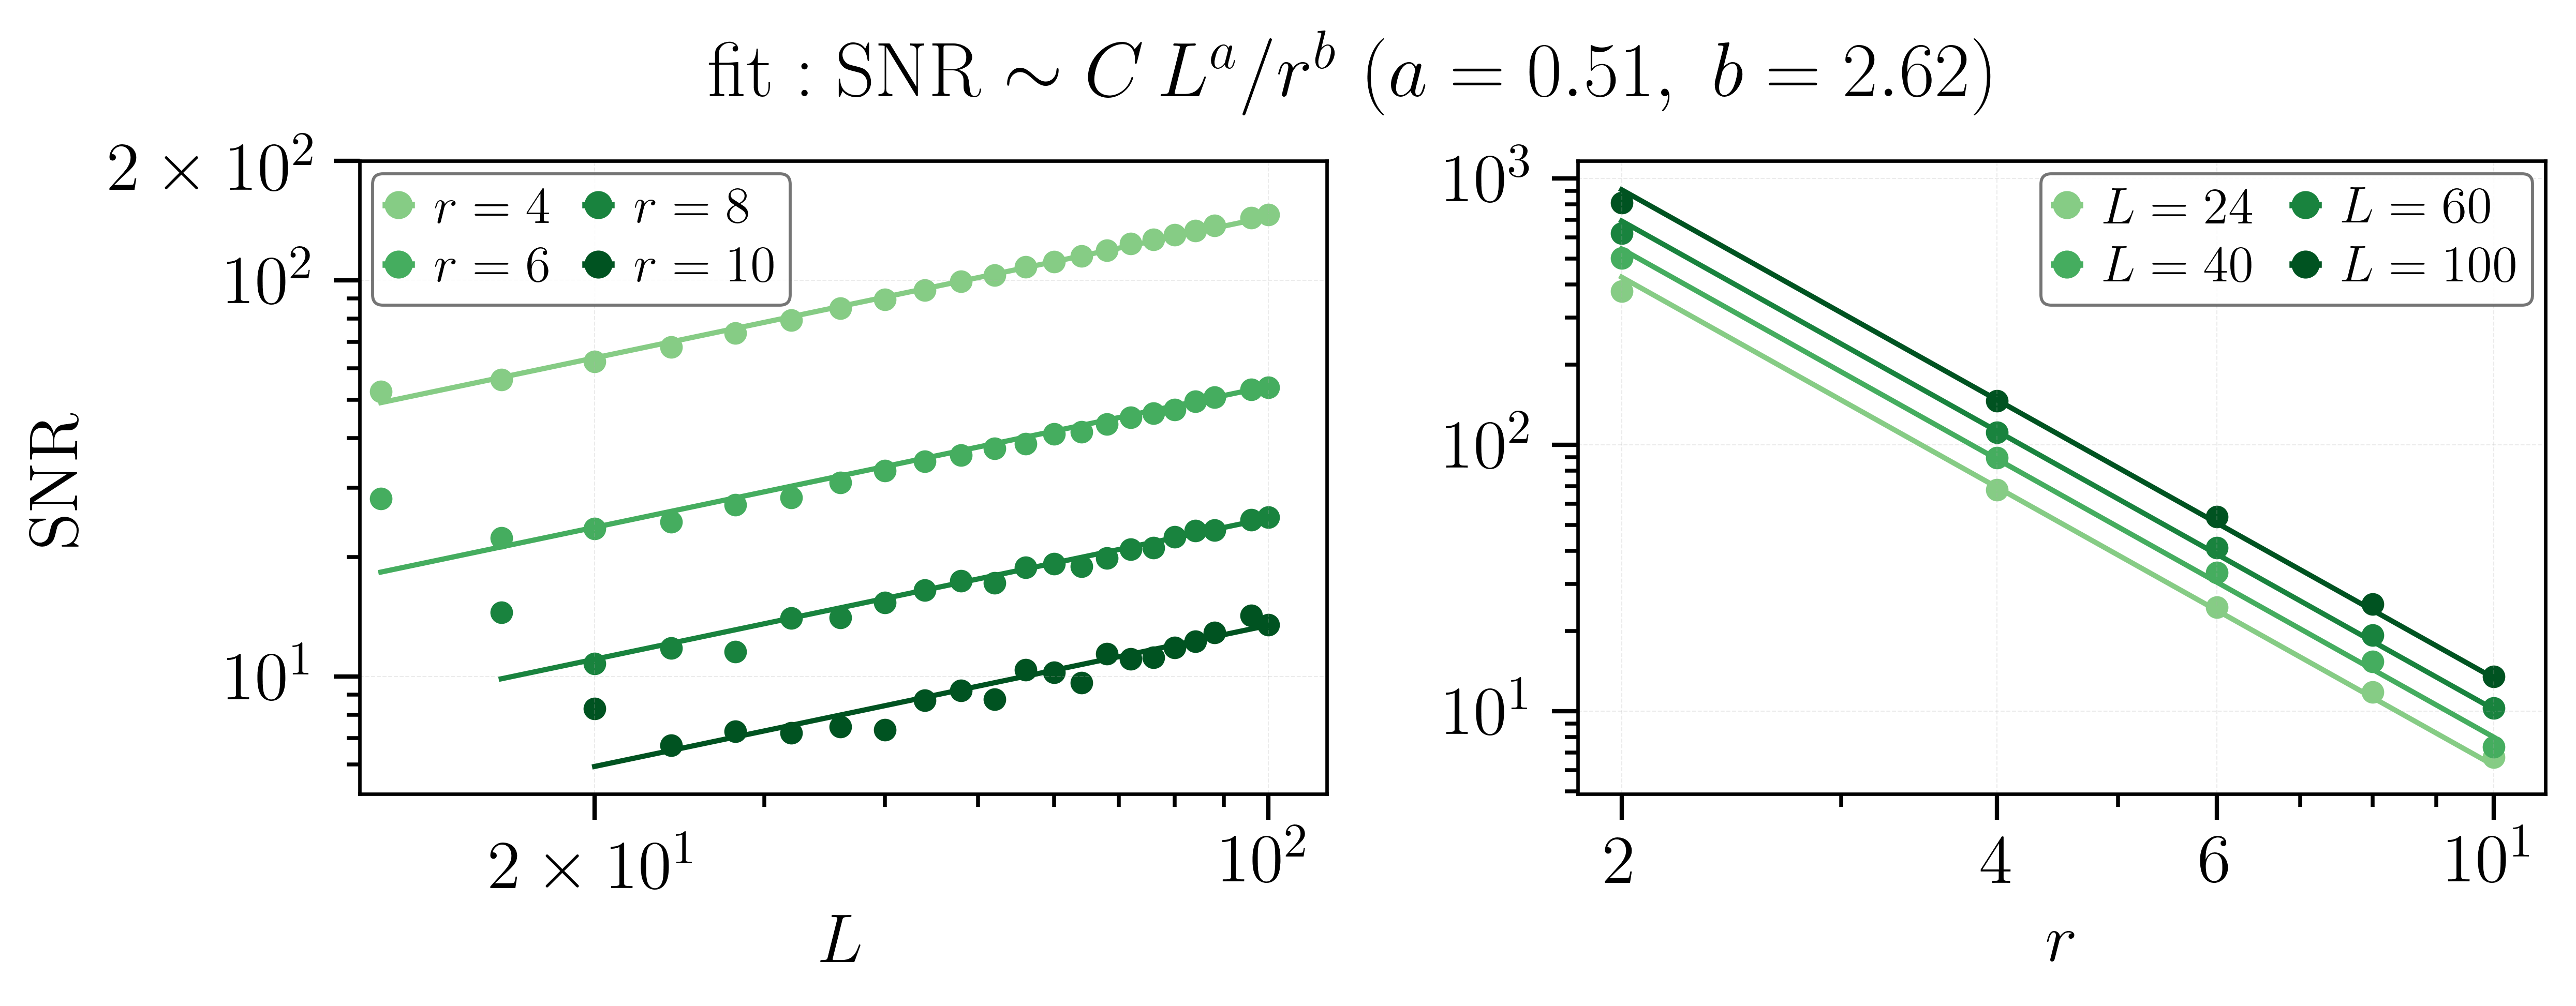

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter, NullLocator, FuncFormatter, NullFormatter

# =============================================================
# =============================================================
csv_file = "heis_sdrg.csv"
snr_col  = "dij_c_snr"
snr_cut_for_fit = 5

# ---------- FIT CUTS ----------
FIT_MIN_L = 20
FIT_MAX_L = 100
FIT_MIN_R = 3
FIT_MAX_R = 40
FIT_R_MAX_FRAC = None

# ---------- PLOT CUTS ----------
PLOT_MIN_L = 1
PLOT_MAX_L = 100
PLOT_MIN_R = None
PLOT_MAX_R = 40
R_MAX_FRAC = None

R_PLOT_DESIRED = [4, 6, 8, 10]
L_PLOT_DESIRED = [24, 40, 60, 100]

R_MAX_RIGHT = 10


L_SAMPLE_RULES = [
    (70, 1),
    (90, 2),
    (100, 3),
]

# =============================================================
# Matplotlib / LaTeX settings
# =============================================================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ROUND_AB     = 2
MARKER_S     = 18

CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Greens

# =============================================================
# =============================================================
def tex_escape(s: str) -> str:
    return (s.replace("\\", r"\textbackslash{}")
             .replace("_", r"\_")
             .replace("%", r"\%")
             .replace("&", r"\&")
             .replace("#", r"\#")
             .replace("{", r"\{")
             .replace("}", r"\}")
             .replace("^", r"\^{}")
             .replace("~", r"\~{}"))

snr_col_tex = tex_escape(snr_col)

# =============================================================
# =============================================================
def fit_snr_scaling_L_over_r(
    df,
    snr_col,
    snr_cut=10.0,
    min_r=None,
    max_r=None,
    min_L=40,
    max_L=None,
    r_max_frac=None,
):
    snr = df[snr_col].to_numpy(dtype=float)
    r   = df["r"].to_numpy(dtype=float)
    L   = df["L"].to_numpy(dtype=float)

    mask = np.isfinite(snr) & np.isfinite(r) & np.isfinite(L)
    mask &= (snr > 0) & (snr >= snr_cut)

    if min_r is not None:
        mask &= (r >= float(min_r))
    if max_r is not None:
        mask &= (r <= float(max_r))
    if min_L is not None:
        mask &= (L >= float(min_L))
    if max_L is not None:
        mask &= (L <= float(max_L))

    if r_max_frac is not None:
        mask &= (r <= float(r_max_frac) * L)

    r_fit   = r[mask]
    L_fit   = L[mask]
    snr_fit = snr[mask]

    n = len(snr_fit)
    if n < 3:
        raise ValueError(f"Not enough data points ({n}) after cuts to fit 3 parameters.")

    log_r   = np.log(r_fit)
    log_L   = np.log(L_fit)
    log_snr = np.log(snr_fit)

    X = np.column_stack([
        np.ones_like(log_L),
        log_L,
        -log_r,
    ])

    beta, residuals, rank, svals = np.linalg.lstsq(X, log_snr, rcond=None)
    logC, a, b = beta

    log_snr_hat = X @ beta
    resid = log_snr - log_snr_hat

    rmse_logsnr = float(np.sqrt(np.mean(resid**2)))

    y = log_snr
    ybar = float(np.mean(y))
    sse = float(np.sum((y - log_snr_hat)**2))
    sst = float(np.sum((y - ybar)**2))
    r2_logsnr = float(1.0 - sse / sst) if sst > 0 else float("nan")

    if residuals.size > 0:
        rss = float(residuals[0])
        dof = n - X.shape[1]
        sigma2 = rss / dof
    else:
        sigma2 = 0.0

    XtX_inv = np.linalg.inv(X.T @ X)
    cov_beta = sigma2 * XtX_inv

    sigma_logC = float(np.sqrt(cov_beta[0, 0]))
    sigma_a    = float(np.sqrt(cov_beta[1, 1]))
    sigma_b    = float(np.sqrt(cov_beta[2, 2]))

    C = float(np.exp(logC))
    sigma_C = float(C * sigma_logC)

    return {
        "C": C, "a": float(a), "b": float(b),
        "sigma_C": sigma_C, "sigma_a": sigma_a, "sigma_b": sigma_b,
        "n_points": int(n),
        "mask": mask,
        "rmse_logsnr": rmse_logsnr,
        "r2_logsnr": r2_logsnr,
    }

# =============================================================
# =============================================================
def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

def color_map_monotone(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = sorted([int(v) for v in values])
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * ts
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

def pick_existing_or_nearest(desired_list, available_list, k=4):
    avail = np.array(sorted(set(int(x) for x in available_list)), dtype=int)
    if avail.size == 0:
        return []
    used, chosen = set(), []

    for d in desired_list:
        d = int(d)
        if d in avail and d not in used:
            chosen.append(d); used.add(d)

    for d in desired_list:
        if len(chosen) >= k:
            break
        d = int(d)
        if d in used:
            continue
        v = int(avail[np.argmin(np.abs(avail - d))])
        if v not in used:
            chosen.append(v); used.add(v)

    if len(chosen) < k:
        rem = [int(x) for x in avail.tolist() if int(x) not in used]
        if rem:
            rem = np.array(rem, dtype=int)
            m = min(k - len(chosen), rem.size)
            idxs = np.linspace(0, rem.size - 1, m).round().astype(int)
            for v in rem[idxs]:
                v = int(v)
                if v not in used and len(chosen) < k:
                    chosen.append(v); used.add(v)

    return sorted(chosen[:k])

def subsample_fixed_r_by_L_rules(sub: pd.DataFrame, rules, L_col_int="Li"):
    """
    Keep a non-uniform subset of L values according to rules, plus endpoints.
    Uses integer L_col_int (rounded/cleaned L). Returns a filtered copy.
    """
    if sub.empty:
        return sub

    Li = sub[L_col_int].to_numpy(dtype=int)
    keep = np.zeros(Li.shape, dtype=bool)

    for Lmax, step in rules:
        Lmax = int(Lmax)
        step = int(step)
        keep |= ((Li <= Lmax) & (Li % step == 0))

    i_min = int(np.argmin(Li))
    i_max = int(np.argmax(Li))
    keep[i_min] = True
    keep[i_max] = True

    if not np.any(keep):
        return sub.copy()

    return sub.loc[keep].copy()

# =============================================================
# =============================================================
df = pd.read_csv(csv_file)
required = {"L", "r", snr_col}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing columns in CSV: {sorted(missing)}")

df = df.copy()
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["r"] = pd.to_numeric(df["r"], errors="coerce")
df[snr_col] = pd.to_numeric(df[snr_col], errors="coerce")

# =============================================================
# =============================================================
res = fit_snr_scaling_L_over_r(
    df, snr_col,
    snr_cut=snr_cut_for_fit,
    min_r=FIT_MIN_R, max_r=FIT_MAX_R,
    min_L=FIT_MIN_L, max_L=FIT_MAX_L,
    r_max_frac=FIT_R_MAX_FRAC
)

a = float(res["a"])
b = float(res["b"])
C = float(res["C"])

print("=== dij_c === ")
print(f" n points used: {res['n_points']}")
print(f" Cuts: SNR>={snr_cut_for_fit}, L>={FIT_MIN_L}, r<={FIT_MAX_R}")
print(f" C = {C:.3g} ± {res['sigma_C']:.3g}")
print(f" a = {a:.3f} ± {res['sigma_a']:.3f}")
print(f" b = {b:.3f} ± {res['sigma_b']:.3f}")
print(f" RMSE(logSNR) = {res['rmse_logsnr']:.4f}")
print(f" R^2(logSNR)  = {res['r2_logsnr']:.4f}")
print()

# =============================================================
# =============================================================
L_all = df["L"].to_numpy(dtype=float)
r_all = df["r"].to_numpy(dtype=float)
snr_all = df[snr_col].to_numpy(dtype=float)

plot_mask = np.isfinite(L_all) & np.isfinite(r_all) & np.isfinite(snr_all)
plot_mask &= (snr_all > 0) & (snr_all >= snr_cut_for_fit)

if PLOT_MIN_L is not None:
    plot_mask &= (L_all >= float(PLOT_MIN_L))
if PLOT_MAX_L is not None:
    plot_mask &= (L_all <= float(PLOT_MAX_L))
if PLOT_MIN_R is not None:
    plot_mask &= (r_all >= float(PLOT_MIN_R))
if PLOT_MAX_R is not None:
    plot_mask &= (r_all <= float(PLOT_MAX_R))

if R_MAX_FRAC is not None:
    plot_mask &= (r_all <= float(R_MAX_FRAC) * L_all)

df_plot = df.loc[plot_mask, ["L", "r", snr_col]].dropna().copy()
if df_plot.empty:
    raise RuntimeError("No points survived plot_mask. Relax PLOT cuts / R_MAX_FRAC.")


df_plot["Li"] = np.rint(df_plot["L"].to_numpy(dtype=float)).astype(int)
df_plot["ri"] = np.rint(df_plot["r"].to_numpy(dtype=float)).astype(int)

if R_MAX_RIGHT is not None:
    df_plot_right = df_plot[df_plot["ri"] <= int(R_MAX_RIGHT)].copy()
else:
    df_plot_right = df_plot.copy()

avail_r = sorted(df_plot["ri"].unique().tolist())
avail_L_right = sorted(df_plot_right["Li"].unique().tolist())

R_PLOT_USE = pick_existing_or_nearest(R_PLOT_DESIRED, avail_r, k=4)
L_PLOT_USE = pick_existing_or_nearest(L_PLOT_DESIRED, avail_L_right, k=4)

print(f"Requested R_PLOT: {R_PLOT_DESIRED} -> using (sorted): {R_PLOT_USE}")
print(f"Requested L_PLOT: {L_PLOT_DESIRED} -> using (sorted): {L_PLOT_USE}")
print()

color_by_r = color_map_monotone(R_PLOT_USE)
color_by_L = color_map_monotone(L_PLOT_USE)

# =============================================================
# Plot
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

def _sci_major_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    mant_r = int(round(mant))

    if exp == 0:
        return rf"${int(round(x))}$"

    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

# -------------------------
# Left panel (fixed r)
# -------------------------
_left_L_all = []
_left_snr_all = []

for r0 in R_PLOT_USE:
    sub = df_plot[df_plot["ri"] == int(r0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("Li")
    sub = subsample_fixed_r_by_L_rules(sub, L_SAMPLE_RULES, L_col_int="Li")

    Ls = sub["L"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _left_L_all.append(Ls)
    _left_snr_all.append(sn)

    col = color_by_r[int(r0)]
    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)

    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax1, xlabel=r"$L$", ylabel=rf"$\mathrm{{SNR}}$")

if _left_L_all:
    Lmin = float(np.min(np.concatenate(_left_L_all)))
    Lmax = float(np.max(np.concatenate(_left_L_all)))
    ax1.set_xlim(left=Lmin * 0.95, right=Lmax * 1.15)

    ax1.set_xticks([20, 100])
    ax1.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax1.xaxis.set_minor_formatter(NullFormatter())

ax1.set_yticks([1e1, 1e2, 2e2])
ax1.yaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
ax1.yaxis.set_minor_formatter(NullFormatter())
# ax1.yaxis.set_minor_locator(NullLocator())

r_handles = []
for r0 in R_PLOT_USE:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# -------------------------
# Right panel (fixed L)
# -------------------------
_right_r_all = []
_right_snr_all = []

for L0 in L_PLOT_USE:
    sub = df_plot_right[df_plot_right["Li"] == int(L0)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("r")
    rs = sub["r"].to_numpy(dtype=float)
    sn = sub[snr_col].to_numpy(dtype=float)

    _right_r_all.append(rs)
    _right_snr_all.append(sn)

    col = color_by_L[int(L0)]
    c0_slice = fit_c0_fixed_L(rs, sn, L0, a, b)

    r_fit = np.logspace(np.log10(rs.min()), np.log10(rs.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b)

    ax2.scatter(rs, sn, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax2, xlabel=r"$r$", ylabel=rf"")

if _right_r_all:
    left_now = ax2.get_xlim()[0]
    if R_MAX_RIGHT is not None:
        r_right = float(R_MAX_RIGHT)
        ax2.set_xlim(left=left_now, right=r_right * 1.1)
    else:
        r_max = float(np.max(np.concatenate(_right_r_all)))
        ax2.set_xlim(left=left_now, right=r_max * 1.1)

    ax2.set_xticks([2, 4, 6,10])
    ax2.xaxis.set_major_formatter(FuncFormatter(_sci_major_fmt))
    ax2.xaxis.set_minor_formatter(NullFormatter())

if _right_snr_all:
    y_min = float(np.min(np.concatenate(_right_snr_all)))
    y0, y1 = ax2.get_ylim()
    ax2.set_ylim(bottom=min(y0, y_min * 0.92), top=y1)

L_handles = []
for L0 in L_PLOT_USE:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

a_leg = round(a, int(ROUND_AB))
b_leg = round(b, int(ROUND_AB))
fig.suptitle(
    rf"$\mathrm{{fit}}: \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$ ($a={a_leg},\ b={b_leg}$)",
    fontsize=18, y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.26)

pdf_name = "Figs/SNR_sc_AFMHeisenberg.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()